In [1]:
import os
import glob
import numpy as np
import rasterio

# -------------------------
# PATHS
# -------------------------
in_root = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\00_Frequency"
out_root = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency"
os.makedirs(out_root, exist_ok=True)

# If your year folders are like "1980", "1981", ... this will work
year_dirs = sorted([d for d in glob.glob(os.path.join(in_root, "*")) if os.path.isdir(d)])

if not year_dirs:
    raise FileNotFoundError(f"No year subfolders found inside: {in_root}")

print(f"Found {len(year_dirs)} year folders.")

for ydir in year_dirs:
    year_name = os.path.basename(ydir)

    # Grab all .tif files in that year folder
    tif_list = sorted(glob.glob(os.path.join(ydir, "*.tif"))) + sorted(glob.glob(os.path.join(ydir, "*.tiff")))

    if len(tif_list) == 0:
        print(f"[SKIP] {year_name}: no tif files found")
        continue

    # Output file name
    out_tif = os.path.join(out_root, f"{year_name}_max.tif")

    # Read first raster to set profile
    with rasterio.open(tif_list[0]) as src0:
        profile = src0.profile.copy()
        nodata = src0.nodata
        # read as float32 so we can safely use nan
        base = src0.read(1).astype(np.float32)

    # Convert NoData -> nan (so nanmax ignores it)
    if nodata is not None:
        base = np.where(base == nodata, np.nan, base)

    # Compute max across all rasters
    current_max = base

    for fp in tif_list[1:]:
        with rasterio.open(fp) as src:
            arr = src.read(1).astype(np.float32)

            # Safety checks (same grid)
            if (src.width != profile["width"] or src.height != profile["height"] or
                src.transform != profile["transform"] or src.crs != profile["crs"]):
                raise ValueError(f"Grid mismatch in year {year_name}: {fp}")

            nd = src.nodata if src.nodata is not None else nodata
            if nd is not None:
                arr = np.where(arr == nd, np.nan, arr)

        current_max = np.nanmax(np.stack([current_max, arr]), axis=0)

    # Decide output nodata
    # If original has nodata, keep it. Otherwise set a nodata.
    out_nodata = nodata if nodata is not None else -9999.0

    # Convert nan -> nodata for writing
    out_arr = np.where(np.isnan(current_max), out_nodata, current_max).astype(np.float32)

    profile.update(dtype=rasterio.float32, count=1, nodata=out_nodata, compress="lzw")

    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(out_arr, 1)

    print(f"[OK] {year_name}: {len(tif_list)} files -> {out_tif}")

print("Done.")


Found 45 year folders.


C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\1489153165.py:61: RuntimeWarning: All-NaN slice encountered
  current_max = np.nanmax(np.stack([current_max, arr]), axis=0)


[OK] 1980: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1980_max.tif
[OK] 1981: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1981_max.tif
[OK] 1982: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1982_max.tif
[OK] 1983: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1983_max.tif
[OK] 1984: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1984_max.tif
[OK] 1985: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1985_max.tif
[OK] 1986: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1986_max.tif
[OK] 1987: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1987_max.tif
[OK] 198

C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\1183933156.py:95: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=1)


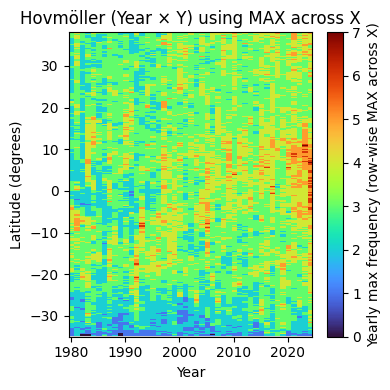


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\hovmoller_year_vs_y_MAX_fixed.png


In [17]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# -------------------------
# INPUTS
# -------------------------
in_dir = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency"
out_png = os.path.join(in_dir, "hovmoller_year_vs_y_MAX_fixed.png")

# ----- IMPORTANT OPTIONS -----
USE_PERCENTILE_STRETCH = False   # False = show true range (so 7 will appear on colorbar if present)
PLOW, PHIGH = 2, 98              # used only if USE_PERCENTILE_STRETCH=True

# If your GeoTIFF wrongly has nodata=7 (or other valid value), override it here:
OVERRIDE_NODATA = None           # e.g., set to -9999 if that's your true NoData; set None to ignore nodata masking

CMAP_NAME = "turbo"              # good vivid map; alternatives: viridis, plasma, inferno, cividis
INTERP = "nearest"

# -------------------------
# FILES + YEARS
# -------------------------
tifs = sorted(glob.glob(os.path.join(in_dir, "*.tif")) + glob.glob(os.path.join(in_dir, "*.tiff")))
if not tifs:
    raise FileNotFoundError(f"No GeoTIFFs found in: {in_dir}")

def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

pairs = [(extract_year(fp), fp) for fp in tifs]
pairs.sort(key=lambda x: x[0])

years = np.array([p[0] for p in pairs], dtype=int)
files = [p[1] for p in pairs]

#print(f"Found {len(files)} yearly max GeoTIFFs from {years.min()} to {years.max()}.")

# -------------------------
# GRID METADATA
# -------------------------
with rasterio.open(files[0]) as src0:
    transform = src0.transform
    crs = src0.crs
    height, width = src0.height, src0.width

# Y coordinate (center of each row)
y0 = transform.f
e = transform.e
y_coords = y0 + e * (np.arange(height) + 0.5)

# -------------------------
# BUILD HOVMOLLER: (time, y) using MAX across X
# -------------------------
H = np.full((len(files), height), np.nan, dtype=np.float32)

global_max_before_mask = -np.inf
global_max_after_mask = -np.inf

for i, fp in enumerate(files):
    with rasterio.open(fp) as src:
        # safety check
        if (src.height != height or src.width != width or
            src.transform != transform or src.crs != crs):
            raise ValueError(f"Grid mismatch vs first raster:\n{fp}")

        arr = src.read(1).astype(np.float32)

        # Diagnostics: max before masking
        year_max_before = np.nanmax(arr)
        global_max_before_mask = max(global_max_before_mask, year_max_before)

        # Decide nodata
        nd = OVERRIDE_NODATA if OVERRIDE_NODATA is not None else src.nodata

        #print(f"{years[i]}  | nodata(meta)={src.nodata}  nodata(used)={nd}  max(before mask)={year_max_before}")

        # Mask nodata ONLY if we decided a nodata value exists
        if nd is not None:
            arr = np.where(arr == nd, np.nan, arr)

        # Diagnostics: max after masking
        year_max_after = np.nanmax(arr) if np.isfinite(arr).any() else np.nan
        if np.isfinite(year_max_after):
            global_max_after_mask = max(global_max_after_mask, year_max_after)

    # Row-wise max across columns (X)
    H[i, :] = np.nanmax(arr, axis=1)

#print("\nOverall max before mask:", global_max_before_mask)
#print("Overall max after  mask:", global_max_after_mask)

# Flip Y if needed
if y_coords[0] > y_coords[-1]:
    y_coords = y_coords[::-1]
    H = H[:, ::-1]

# -------------------------
# COLOR LIMITS
# -------------------------
finite_vals = H[np.isfinite(H)]
if finite_vals.size == 0:
    raise ValueError("All values became NaN. This strongly suggests nodata masking is wrong (e.g., nodata=valid value).")

if USE_PERCENTILE_STRETCH:
    vmin, vmax = np.percentile(finite_vals, [PLOW, PHIGH])
else:
    vmin, vmax = float(np.min(finite_vals)), float(np.max(finite_vals))

#print(f"Color scale vmin={vmin}, vmax={vmax}")

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(4, 4))
extent = [years.min() - 0.5, years.max() + 0.5, y_coords.min(), y_coords.max()]

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

im = plt.imshow(
    H.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation=INTERP
)

cbar = plt.colorbar(im)
cbar.set_label("Yearly max frequency (row-wise MAX across X)")

plt.xlabel("Year")
plt.ylabel("Latitude (degrees)" if (crs and crs.is_geographic) else "Y (northing / row coord)")
plt.title("Hovmöller (Year × Y) using MAX across X")
plt.tight_layout()
plt.savefig(out_png, dpi=900)
plt.show()

print(f"\nSaved: {out_png}")


In [18]:
import os
import glob
import numpy as np
import rasterio

# -------------------------
# PATHS
# -------------------------
in_root = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\01_Duration"
out_root = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration"
os.makedirs(out_root, exist_ok=True)

# If your year folders are like "1980", "1981", ... this will work
year_dirs = sorted([d for d in glob.glob(os.path.join(in_root, "*")) if os.path.isdir(d)])

if not year_dirs:
    raise FileNotFoundError(f"No year subfolders found inside: {in_root}")

print(f"Found {len(year_dirs)} year folders.")

for ydir in year_dirs:
    year_name = os.path.basename(ydir)

    # Grab all .tif files in that year folder
    tif_list = sorted(glob.glob(os.path.join(ydir, "*.tif"))) + sorted(glob.glob(os.path.join(ydir, "*.tiff")))

    if len(tif_list) == 0:
        print(f"[SKIP] {year_name}: no tif files found")
        continue

    # Output file name
    out_tif = os.path.join(out_root, f"{year_name}_max.tif")

    # Read first raster to set profile
    with rasterio.open(tif_list[0]) as src0:
        profile = src0.profile.copy()
        nodata = src0.nodata
        # read as float32 so we can safely use nan
        base = src0.read(1).astype(np.float32)

    # Convert NoData -> nan (so nanmax ignores it)
    if nodata is not None:
        base = np.where(base == nodata, np.nan, base)

    # Compute max across all rasters
    current_max = base

    for fp in tif_list[1:]:
        with rasterio.open(fp) as src:
            arr = src.read(1).astype(np.float32)

            # Safety checks (same grid)
            if (src.width != profile["width"] or src.height != profile["height"] or
                src.transform != profile["transform"] or src.crs != profile["crs"]):
                raise ValueError(f"Grid mismatch in year {year_name}: {fp}")

            nd = src.nodata if src.nodata is not None else nodata
            if nd is not None:
                arr = np.where(arr == nd, np.nan, arr)

        current_max = np.nanmax(np.stack([current_max, arr]), axis=0)

    # Decide output nodata
    # If original has nodata, keep it. Otherwise set a nodata.
    out_nodata = nodata if nodata is not None else -9999.0

    # Convert nan -> nodata for writing
    out_arr = np.where(np.isnan(current_max), out_nodata, current_max).astype(np.float32)

    profile.update(dtype=rasterio.float32, count=1, nodata=out_nodata, compress="lzw")

    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(out_arr, 1)

    print(f"[OK] {year_name}: {len(tif_list)} files -> {out_tif}")

print("Done.")


Found 45 year folders.


C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\2673485368.py:61: RuntimeWarning: All-NaN slice encountered
  current_max = np.nanmax(np.stack([current_max, arr]), axis=0)


[OK] 1980: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\1980_max.tif
[OK] 1981: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\1981_max.tif
[OK] 1982: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\1982_max.tif
[OK] 1983: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\1983_max.tif
[OK] 1984: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\1984_max.tif
[OK] 1985: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\1985_max.tif
[OK] 1986: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\1986_max.tif
[OK] 1987: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\1987_max.tif
[OK] 1988: 12 fi

C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\251689620.py:95: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=1)


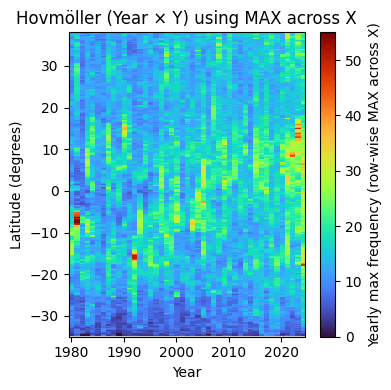


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration\dur_hovmoller_year_vs_y_MAX_fixed.png


In [19]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# -------------------------
# INPUTS
# -------------------------
in_dir = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\01_Duration"
out_png = os.path.join(in_dir, "dur_hovmoller_year_vs_y_MAX_fixed.png")

# ----- IMPORTANT OPTIONS -----
USE_PERCENTILE_STRETCH = False   # False = show true range (so 7 will appear on colorbar if present)
PLOW, PHIGH = 2, 98              # used only if USE_PERCENTILE_STRETCH=True

# If your GeoTIFF wrongly has nodata=7 (or other valid value), override it here:
OVERRIDE_NODATA = None           # e.g., set to -9999 if that's your true NoData; set None to ignore nodata masking

CMAP_NAME = "turbo"              # good vivid map; alternatives: viridis, plasma, inferno, cividis
INTERP = "nearest"

# -------------------------
# FILES + YEARS
# -------------------------
tifs = sorted(glob.glob(os.path.join(in_dir, "*.tif")) + glob.glob(os.path.join(in_dir, "*.tiff")))
if not tifs:
    raise FileNotFoundError(f"No GeoTIFFs found in: {in_dir}")

def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

pairs = [(extract_year(fp), fp) for fp in tifs]
pairs.sort(key=lambda x: x[0])

years = np.array([p[0] for p in pairs], dtype=int)
files = [p[1] for p in pairs]

#print(f"Found {len(files)} yearly max GeoTIFFs from {years.min()} to {years.max()}.")

# -------------------------
# GRID METADATA
# -------------------------
with rasterio.open(files[0]) as src0:
    transform = src0.transform
    crs = src0.crs
    height, width = src0.height, src0.width

# Y coordinate (center of each row)
y0 = transform.f
e = transform.e
y_coords = y0 + e * (np.arange(height) + 0.5)

# -------------------------
# BUILD HOVMOLLER: (time, y) using MAX across X
# -------------------------
H = np.full((len(files), height), np.nan, dtype=np.float32)

global_max_before_mask = -np.inf
global_max_after_mask = -np.inf

for i, fp in enumerate(files):
    with rasterio.open(fp) as src:
        # safety check
        if (src.height != height or src.width != width or
            src.transform != transform or src.crs != crs):
            raise ValueError(f"Grid mismatch vs first raster:\n{fp}")

        arr = src.read(1).astype(np.float32)

        # Diagnostics: max before masking
        year_max_before = np.nanmax(arr)
        global_max_before_mask = max(global_max_before_mask, year_max_before)

        # Decide nodata
        nd = OVERRIDE_NODATA if OVERRIDE_NODATA is not None else src.nodata

        #print(f"{years[i]}  | nodata(meta)={src.nodata}  nodata(used)={nd}  max(before mask)={year_max_before}")

        # Mask nodata ONLY if we decided a nodata value exists
        if nd is not None:
            arr = np.where(arr == nd, np.nan, arr)

        # Diagnostics: max after masking
        year_max_after = np.nanmax(arr) if np.isfinite(arr).any() else np.nan
        if np.isfinite(year_max_after):
            global_max_after_mask = max(global_max_after_mask, year_max_after)

    # Row-wise max across columns (X)
    H[i, :] = np.nanmax(arr, axis=1)

#print("\nOverall max before mask:", global_max_before_mask)
#print("Overall max after  mask:", global_max_after_mask)

# Flip Y if needed
if y_coords[0] > y_coords[-1]:
    y_coords = y_coords[::-1]
    H = H[:, ::-1]

# -------------------------
# COLOR LIMITS
# -------------------------
finite_vals = H[np.isfinite(H)]
if finite_vals.size == 0:
    raise ValueError("All values became NaN. This strongly suggests nodata masking is wrong (e.g., nodata=valid value).")

if USE_PERCENTILE_STRETCH:
    vmin, vmax = np.percentile(finite_vals, [PLOW, PHIGH])
else:
    vmin, vmax = float(np.min(finite_vals)), float(np.max(finite_vals))

#print(f"Color scale vmin={vmin}, vmax={vmax}")

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(4, 4))
extent = [years.min() - 0.5, years.max() + 0.5, y_coords.min(), y_coords.max()]

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

im = plt.imshow(
    H.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation=INTERP
)

cbar = plt.colorbar(im)
cbar.set_label("Yearly max frequency (row-wise MAX across X)")

plt.xlabel("Year")
plt.ylabel("Latitude (degrees)" if (crs and crs.is_geographic) else "Y (northing / row coord)")
plt.title("Hovmöller (Year × Y) using MAX across X")
plt.tight_layout()
plt.savefig(out_png, dpi=900)
plt.show()

print(f"\nSaved: {out_png}")


In [20]:
import os
import glob
import numpy as np
import rasterio

# -------------------------
# PATHS
# -------------------------
in_root = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\02_Intensity"
out_root = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity"
os.makedirs(out_root, exist_ok=True)

# If your year folders are like "1980", "1981", ... this will work
year_dirs = sorted([d for d in glob.glob(os.path.join(in_root, "*")) if os.path.isdir(d)])

if not year_dirs:
    raise FileNotFoundError(f"No year subfolders found inside: {in_root}")

print(f"Found {len(year_dirs)} year folders.")

for ydir in year_dirs:
    year_name = os.path.basename(ydir)

    # Grab all .tif files in that year folder
    tif_list = sorted(glob.glob(os.path.join(ydir, "*.tif"))) + sorted(glob.glob(os.path.join(ydir, "*.tiff")))

    if len(tif_list) == 0:
        print(f"[SKIP] {year_name}: no tif files found")
        continue

    # Output file name
    out_tif = os.path.join(out_root, f"{year_name}_max.tif")

    # Read first raster to set profile
    with rasterio.open(tif_list[0]) as src0:
        profile = src0.profile.copy()
        nodata = src0.nodata
        # read as float32 so we can safely use nan
        base = src0.read(1).astype(np.float32)

    # Convert NoData -> nan (so nanmax ignores it)
    if nodata is not None:
        base = np.where(base == nodata, np.nan, base)

    # Compute max across all rasters
    current_max = base

    for fp in tif_list[1:]:
        with rasterio.open(fp) as src:
            arr = src.read(1).astype(np.float32)

            # Safety checks (same grid)
            if (src.width != profile["width"] or src.height != profile["height"] or
                src.transform != profile["transform"] or src.crs != profile["crs"]):
                raise ValueError(f"Grid mismatch in year {year_name}: {fp}")

            nd = src.nodata if src.nodata is not None else nodata
            if nd is not None:
                arr = np.where(arr == nd, np.nan, arr)

        current_max = np.nanmax(np.stack([current_max, arr]), axis=0)

    # Decide output nodata
    # If original has nodata, keep it. Otherwise set a nodata.
    out_nodata = nodata if nodata is not None else -9999.0

    # Convert nan -> nodata for writing
    out_arr = np.where(np.isnan(current_max), out_nodata, current_max).astype(np.float32)

    profile.update(dtype=rasterio.float32, count=1, nodata=out_nodata, compress="lzw")

    with rasterio.open(out_tif, "w", **profile) as dst:
        dst.write(out_arr, 1)

    print(f"[OK] {year_name}: {len(tif_list)} files -> {out_tif}")

print("Done.")


Found 45 year folders.


C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\1555137725.py:61: RuntimeWarning: All-NaN slice encountered
  current_max = np.nanmax(np.stack([current_max, arr]), axis=0)


[OK] 1980: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\1980_max.tif
[OK] 1981: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\1981_max.tif
[OK] 1982: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\1982_max.tif
[OK] 1983: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\1983_max.tif
[OK] 1984: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\1984_max.tif
[OK] 1985: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\1985_max.tif
[OK] 1986: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\1986_max.tif
[OK] 1987: 12 files -> D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\1987_max.tif
[OK] 198

C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\3402370642.py:95: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=1)


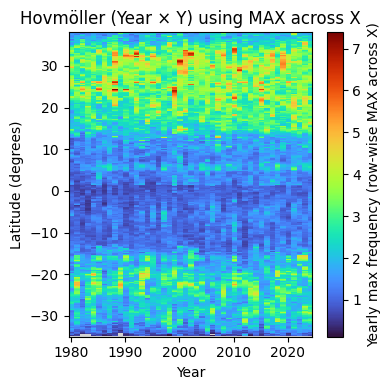


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\Int_hovmoller_year_vs_y_MAX_fixed.png


In [21]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# -------------------------
# INPUTS
# -------------------------
in_dir = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity"
out_png = os.path.join(in_dir, "Int_hovmoller_year_vs_y_MAX_fixed.png")

# ----- IMPORTANT OPTIONS -----
USE_PERCENTILE_STRETCH = False   # False = show true range (so 7 will appear on colorbar if present)
PLOW, PHIGH = 2, 98              # used only if USE_PERCENTILE_STRETCH=True

# If your GeoTIFF wrongly has nodata=7 (or other valid value), override it here:
OVERRIDE_NODATA = None           # e.g., set to -9999 if that's your true NoData; set None to ignore nodata masking

CMAP_NAME = "turbo"              # good vivid map; alternatives: viridis, plasma, inferno, cividis
INTERP = "nearest"

# -------------------------
# FILES + YEARS
# -------------------------
tifs = sorted(glob.glob(os.path.join(in_dir, "*.tif")) + glob.glob(os.path.join(in_dir, "*.tiff")))
if not tifs:
    raise FileNotFoundError(f"No GeoTIFFs found in: {in_dir}")

def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

pairs = [(extract_year(fp), fp) for fp in tifs]
pairs.sort(key=lambda x: x[0])

years = np.array([p[0] for p in pairs], dtype=int)
files = [p[1] for p in pairs]

#print(f"Found {len(files)} yearly max GeoTIFFs from {years.min()} to {years.max()}.")

# -------------------------
# GRID METADATA
# -------------------------
with rasterio.open(files[0]) as src0:
    transform = src0.transform
    crs = src0.crs
    height, width = src0.height, src0.width

# Y coordinate (center of each row)
y0 = transform.f
e = transform.e
y_coords = y0 + e * (np.arange(height) + 0.5)

# -------------------------
# BUILD HOVMOLLER: (time, y) using MAX across X
# -------------------------
H = np.full((len(files), height), np.nan, dtype=np.float32)

global_max_before_mask = -np.inf
global_max_after_mask = -np.inf

for i, fp in enumerate(files):
    with rasterio.open(fp) as src:
        # safety check
        if (src.height != height or src.width != width or
            src.transform != transform or src.crs != crs):
            raise ValueError(f"Grid mismatch vs first raster:\n{fp}")

        arr = src.read(1).astype(np.float32)

        # Diagnostics: max before masking
        year_max_before = np.nanmax(arr)
        global_max_before_mask = max(global_max_before_mask, year_max_before)

        # Decide nodata
        nd = OVERRIDE_NODATA if OVERRIDE_NODATA is not None else src.nodata

        #print(f"{years[i]}  | nodata(meta)={src.nodata}  nodata(used)={nd}  max(before mask)={year_max_before}")

        # Mask nodata ONLY if we decided a nodata value exists
        if nd is not None:
            arr = np.where(arr == nd, np.nan, arr)

        # Diagnostics: max after masking
        year_max_after = np.nanmax(arr) if np.isfinite(arr).any() else np.nan
        if np.isfinite(year_max_after):
            global_max_after_mask = max(global_max_after_mask, year_max_after)

    # Row-wise max across columns (X)
    H[i, :] = np.nanmax(arr, axis=1)

#print("\nOverall max before mask:", global_max_before_mask)
#print("Overall max after  mask:", global_max_after_mask)

# Flip Y if needed
if y_coords[0] > y_coords[-1]:
    y_coords = y_coords[::-1]
    H = H[:, ::-1]

# -------------------------
# COLOR LIMITS
# -------------------------
finite_vals = H[np.isfinite(H)]
if finite_vals.size == 0:
    raise ValueError("All values became NaN. This strongly suggests nodata masking is wrong (e.g., nodata=valid value).")

if USE_PERCENTILE_STRETCH:
    vmin, vmax = np.percentile(finite_vals, [PLOW, PHIGH])
else:
    vmin, vmax = float(np.min(finite_vals)), float(np.max(finite_vals))

#print(f"Color scale vmin={vmin}, vmax={vmax}")

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(4, 4))
extent = [years.min() - 0.5, years.max() + 0.5, y_coords.min(), y_coords.max()]

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

im = plt.imshow(
    H.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation=INTERP
)

cbar = plt.colorbar(im)
cbar.set_label("Yearly max frequency (row-wise MAX across X)")

plt.xlabel("Year")
plt.ylabel("Latitude (degrees)" if (crs and crs.is_geographic) else "Y (northing / row coord)")
plt.title("Hovmöller (Year × Y) using MAX across X")
plt.tight_layout()
plt.savefig(out_png, dpi=900)
plt.show()

print(f"\nSaved: {out_png}")


C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\1896891105.py:75: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=1)


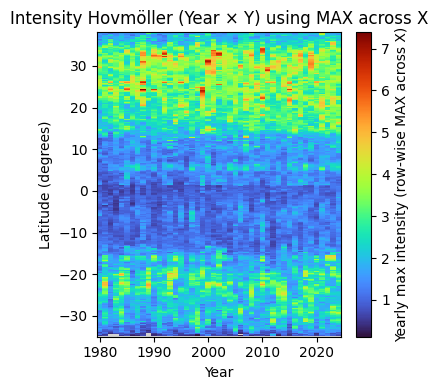


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\Intensity_hovmoller_year_vs_y_MAX.png


In [23]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# -------------------------
# INPUTS
# -------------------------
in_dir = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity"
out_png = os.path.join(in_dir, "Intensity_hovmoller_year_vs_y_MAX.png")

# ----- IMPORTANT OPTIONS -----
USE_PERCENTILE_STRETCH = False   # True if you want robust contrast for intensity
PLOW, PHIGH = 2, 98

OVERRIDE_NODATA = None

CMAP_NAME = "turbo"
INTERP = "nearest"

# -------------------------
# FILES + YEARS
# -------------------------
tifs = sorted(glob.glob(os.path.join(in_dir, "*.tif")) + glob.glob(os.path.join(in_dir, "*.tiff")))
if not tifs:
    raise FileNotFoundError(f"No GeoTIFFs found in: {in_dir}")

def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

pairs = [(extract_year(fp), fp) for fp in tifs]
pairs.sort(key=lambda x: x[0])

years = np.array([p[0] for p in pairs], dtype=int)
files = [p[1] for p in pairs]

# -------------------------
# GRID METADATA
# -------------------------
with rasterio.open(files[0]) as src0:
    transform = src0.transform
    crs = src0.crs
    height, width = src0.height, src0.width

# Y coordinate (center of each row)
y0 = transform.f
e = transform.e
y_coords = y0 + e * (np.arange(height) + 0.5)

# -------------------------
# BUILD HOVMOLLER: (time, y) using MAX across X
# -------------------------
H = np.full((len(files), height), np.nan, dtype=np.float32)

for i, fp in enumerate(files):
    with rasterio.open(fp) as src:
        # safety check
        if (src.height != height or src.width != width or
            src.transform != transform or src.crs != crs):
            raise ValueError(f"Grid mismatch vs first raster:\n{fp}")

        arr = src.read(1).astype(np.float32)

        nd = OVERRIDE_NODATA if OVERRIDE_NODATA is not None else src.nodata
        if nd is not None:
            arr = np.where(arr == nd, np.nan, arr)

    # Row-wise max across columns (X)
    H[i, :] = np.nanmax(arr, axis=1)

# Flip Y if needed
if y_coords[0] > y_coords[-1]:
    y_coords = y_coords[::-1]
    H = H[:, ::-1]

# -------------------------
# COLOR LIMITS
# -------------------------
finite_vals = H[np.isfinite(H)]
if finite_vals.size == 0:
    raise ValueError("All values became NaN. Check nodata handling.")

if USE_PERCENTILE_STRETCH:
    vmin, vmax = np.percentile(finite_vals, [PLOW, PHIGH])
else:
    vmin, vmax = float(np.min(finite_vals)), float(np.max(finite_vals))

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(4, 4))
extent = [years.min() - 0.5, years.max() + 0.5, y_coords.min(), y_coords.max()]

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

im = plt.imshow(
    H.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation=INTERP
)

cbar = plt.colorbar(im)
cbar.set_label("Yearly max intensity (row-wise MAX across X)")

plt.xlabel("Year")
plt.ylabel("Latitude (degrees)" if (crs and crs.is_geographic) else "Y (northing / row coord)")
plt.title("Intensity Hovmöller (Year × Y) using MAX across X")
plt.tight_layout()
plt.savefig(out_png, dpi=900)
plt.show()

print(f"\nSaved: {out_png}")


Found 45 yearly max GeoTIFFs from 1980 to 2024.


C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\2958518480.py:77: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=1)


Color scale vmin=0.7337811374664307, vmax=4.5287602996826175


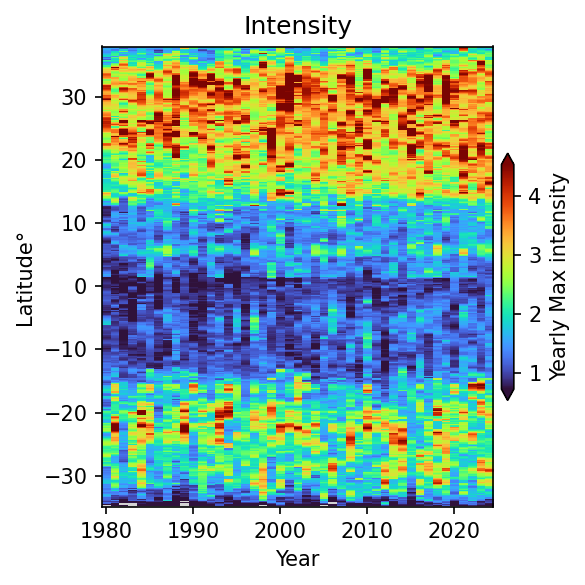


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity\Int_hovmoller_year_vs_y_MAX.png


In [29]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# -------------------------
# INPUTS
# -------------------------
in_dir = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\02_Intensity"
out_png = os.path.join(in_dir, "Int_hovmoller_year_vs_y_MAX.png")

# Better for intensity visuals (optional, but recommended)
USE_PERCENTILE_STRETCH = True
PLOW, PHIGH = 2, 98

OVERRIDE_NODATA = None

CMAP_NAME = "turbo"
INTERP = "nearest"

# -------------------------
# FILES + YEARS
# -------------------------
tifs = sorted(glob.glob(os.path.join(in_dir, "*.tif")) + glob.glob(os.path.join(in_dir, "*.tiff")))
if not tifs:
    raise FileNotFoundError(f"No GeoTIFFs found in: {in_dir}")

def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

pairs = [(extract_year(fp), fp) for fp in tifs]
pairs.sort(key=lambda x: x[0])

years = np.array([p[0] for p in pairs], dtype=int)
files = [p[1] for p in pairs]

print(f"Found {len(files)} yearly max GeoTIFFs from {years.min()} to {years.max()}.")

# -------------------------
# GRID METADATA
# -------------------------
with rasterio.open(files[0]) as src0:
    transform = src0.transform
    crs = src0.crs
    height, width = src0.height, src0.width

# Y coordinate (center of each row)
y0 = transform.f
e = transform.e
y_coords = y0 + e * (np.arange(height) + 0.5)

# -------------------------
# BUILD HOVMOLLER: (time, y) using MAX across X
# -------------------------
H = np.full((len(files), height), np.nan, dtype=np.float32)

for i, fp in enumerate(files):
    with rasterio.open(fp) as src:
        # safety check
        if (src.height != height or src.width != width or
            src.transform != transform or src.crs != crs):
            raise ValueError(f"Grid mismatch vs first raster:\n{fp}")

        arr = src.read(1).astype(np.float32)

        nd = OVERRIDE_NODATA if OVERRIDE_NODATA is not None else src.nodata
        if nd is not None:
            arr = np.where(arr == nd, np.nan, arr)

    # Row-wise max across columns (X)
    H[i, :] = np.nanmax(arr, axis=1)

# Flip Y if needed
if y_coords[0] > y_coords[-1]:
    y_coords = y_coords[::-1]
    H = H[:, ::-1]

# -------------------------
# COLOR LIMITS
# -------------------------
finite_vals = H[np.isfinite(H)]
if finite_vals.size == 0:
    raise ValueError("All values became NaN. Check nodata handling.")

if USE_PERCENTILE_STRETCH:
    vmin, vmax = np.percentile(finite_vals, [PLOW, PHIGH])
else:
    vmin, vmax = float(np.min(finite_vals)), float(np.max(finite_vals))

print(f"Color scale vmin={vmin}, vmax={vmax}")

# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)

extent = [years.min() - 0.5, years.max() + 0.5, y_coords.min(), y_coords.max()]

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

im = ax.imshow(
    H.T,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation=INTERP
)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, extend="both")
cbar.set_label("Yearly Max intensity")

ax.set_xlabel("Year")
ax.set_ylabel("Latitude°" if (crs and crs.is_geographic) else "Y (northing / row coord)")
ax.set_title("Intensity")

fig.tight_layout()
fig.savefig(out_png, dpi=400)
plt.show()

print(f"\nSaved: {out_png}")


Frequency: 45 files (1980–2024)


C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\2493617182.py:90: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=1)


  Frequency true max = 7.000 | colorbar vmax = 7.000
Duration: 45 files (1980–2024)
  Duration true max = 55.000 | colorbar vmax = 55.000
Intensity: 45 files (1980–2024)
  Intensity true max = 7.388 | colorbar vmax = 7.388


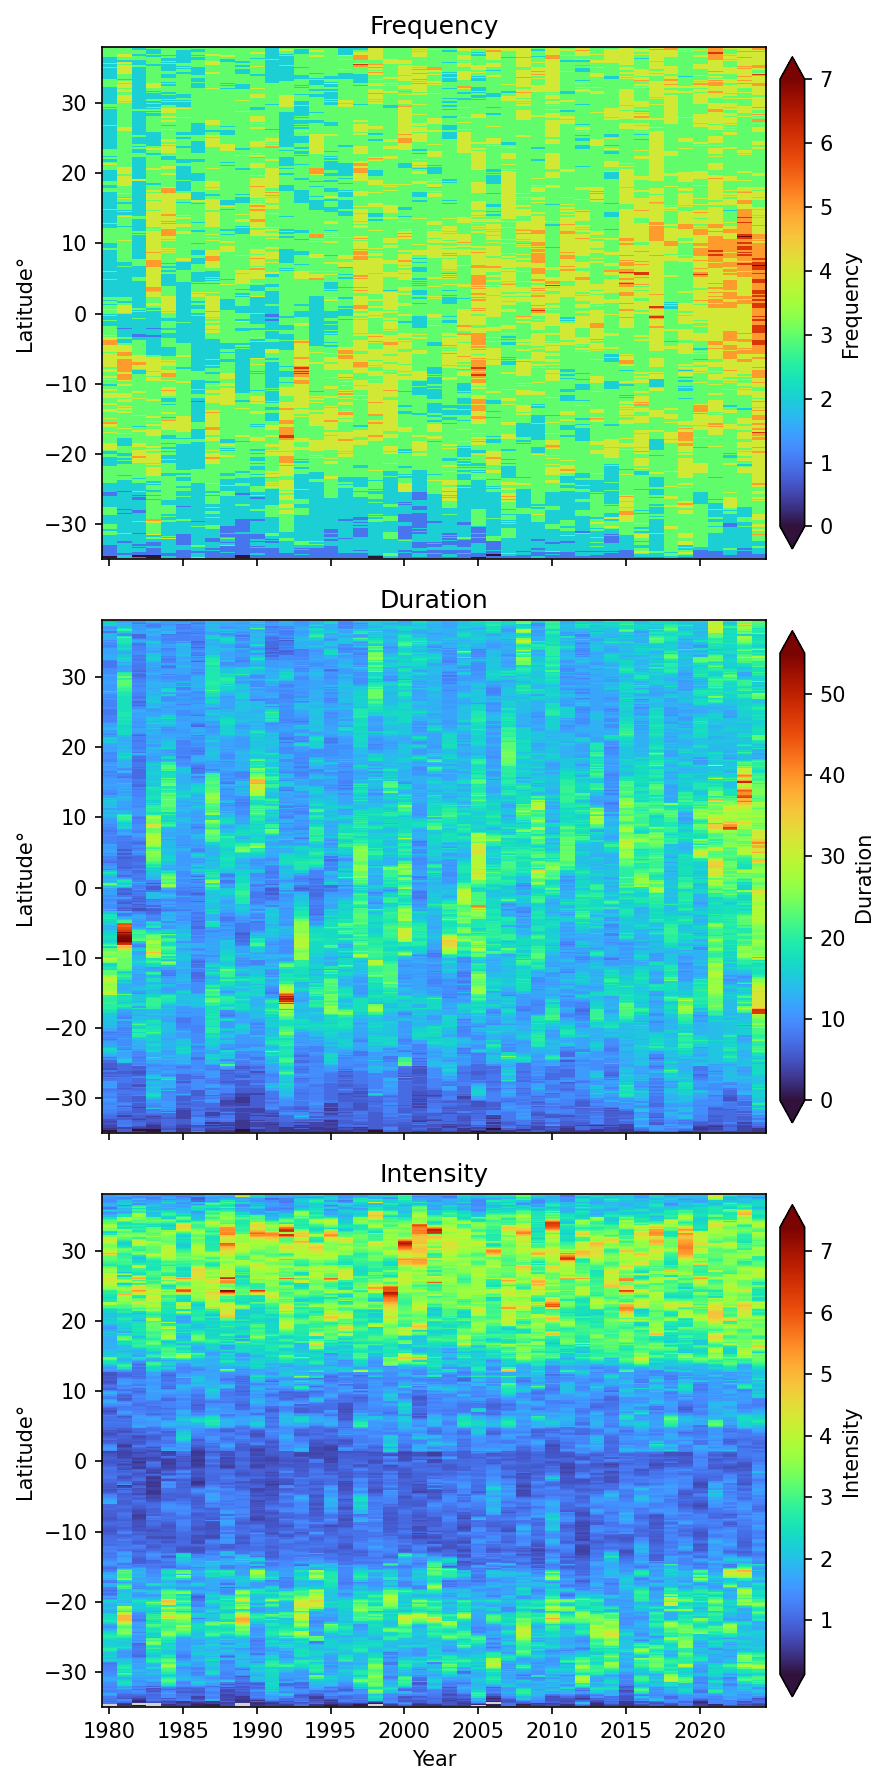


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_3x1_Frequency_Duration_Intensity.png


In [34]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================
BASE = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max"
OUT_PNG = os.path.join(BASE, "hovmoller_3x1_Frequency_Duration_Intensity.png")

DIRS = {
    "Frequency": os.path.join(BASE, "00_Frequency"),
    "Duration":  os.path.join(BASE, "01_Duration"),
    "Intensity": os.path.join(BASE, "02_Intensity"),
}

# ============================================================
# PER-VARIABLE COLOR SCALING
#   - Frequency uses TRUE min/max so max=7 will show
#   - Duration/Intensity use percentiles for better contrast
# ============================================================
SCALE = {
    "Frequency": {"use_percentile": False, "plow": 2, "phigh": 98},
    "Duration":  {"use_percentile": False,  "plow": 2, "phigh": 98},
    "Intensity": {"use_percentile": False,  "plow": 2, "phigh": 98},
}

CMAP_NAME = "turbo"
INTERP = "nearest"

# If nodata metadata is wrong (e.g., nodata=7 but 7 is real), set real nodata here (e.g., -9999).
OVERRIDE_NODATA = None

FIGSIZE = (6, 12)   # 3x1 figure
DPI_SHOW = 150
DPI_SAVE = 400

# ============================================================
# HELPERS
# ============================================================
def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

def list_year_tifs(folder):
    tifs = sorted(glob.glob(os.path.join(folder, "*.tif")) + glob.glob(os.path.join(folder, "*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No GeoTIFFs found in: {folder}")
    pairs = [(extract_year(fp), fp) for fp in tifs]
    pairs.sort(key=lambda x: x[0])
    years = np.array([p[0] for p in pairs], dtype=int)
    files = [p[1] for p in pairs]
    return years, files

def build_hovmoller(files, grid_ref=None):
    """H[time, y] = max across X (columns) for each Y row."""
    with rasterio.open(files[0]) as src0:
        transform = src0.transform
        crs = src0.crs
        height, width = src0.height, src0.width

    if grid_ref is not None:
        if (height != grid_ref["height"] or width != grid_ref["width"] or
            transform != grid_ref["transform"] or crs != grid_ref["crs"]):
            raise ValueError("Grid mismatch between variables (Frequency/Duration/Intensity).")

    y0 = transform.f
    e = transform.e
    y_coords = y0 + e * (np.arange(height) + 0.5)

    H = np.full((len(files), height), np.nan, dtype=np.float32)

    for i, fp in enumerate(files):
        with rasterio.open(fp) as src:
            if (src.height != height or src.width != width or
                src.transform != transform or src.crs != crs):
                raise ValueError(f"Grid mismatch within folder at:\n{fp}")

            arr = src.read(1).astype(np.float32)
            nd = OVERRIDE_NODATA if OVERRIDE_NODATA is not None else src.nodata
            if nd is not None:
                arr = np.where(arr == nd, np.nan, arr)

        H[i, :] = np.nanmax(arr, axis=1)

    if y_coords[0] > y_coords[-1]:
        y_coords = y_coords[::-1]
        H = H[:, ::-1]

    return y_coords, H, crs, transform, height, width

def get_vmin_vmax(H, use_percentile, plow, phigh):
    vals = H[np.isfinite(H)]
    if vals.size == 0:
        raise ValueError("All values became NaN. Check nodata handling.")
    if use_percentile:
        return np.percentile(vals, [plow, phigh])
    return float(np.min(vals)), float(np.max(vals))

# ============================================================
# LOAD ALL THREE
# ============================================================
data = {}
years_common = None
grid_ref = None
y_coords = None

for name, folder in DIRS.items():
    years, files = list_year_tifs(folder)
    print(f"{name}: {len(files)} files ({years.min()}–{years.max()})")

    if years_common is None:
        years_common = years
    else:
        if not np.array_equal(years_common, years):
            raise ValueError(f"Years mismatch for {name}. Make sure all folders have the same years/files.")

    y_coords, H, crs, transform, height, width = build_hovmoller(files, grid_ref=grid_ref)

    if grid_ref is None:
        grid_ref = {"height": height, "width": width, "transform": transform, "crs": crs}

    sc = SCALE[name]
    vmin, vmax = get_vmin_vmax(H, sc["use_percentile"], sc["plow"], sc["phigh"])

    print(f"  {name} true max = {np.nanmax(H):.3f} | colorbar vmax = {vmax:.3f}")

    data[name] = dict(H=H, vmin=vmin, vmax=vmax)

extent = [years_common.min() - 0.5, years_common.max() + 0.5, y_coords.min(), y_coords.max()]

# ============================================================
# PLOT 3x1
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE, dpi=DPI_SHOW, sharex=True, sharey=True)

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

for ax, name in zip(axes, ["Frequency", "Duration", "Intensity"]):
    H = data[name]["H"]
    vmin = data[name]["vmin"]
    vmax = data[name]["vmax"]

    im = ax.imshow(
        H.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation=INTERP
    )

    ax.set_title(name)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, extend="both")
    cbar.set_label(name)

axes[-1].set_xlabel("Year")
if grid_ref["crs"] and grid_ref["crs"].is_geographic:
    axes[0].set_ylabel("Latitude°")
    axes[1].set_ylabel("Latitude°")
    axes[2].set_ylabel("Latitude°")
else:
    axes[0].set_ylabel("Y (northing / row coord)")

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=DPI_SAVE)
plt.show()

print(f"\nSaved: {OUT_PNG}")


C:\Users\maharjan\AppData\Local\Temp\ipykernel_39872\2580807050.py:92: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=1)


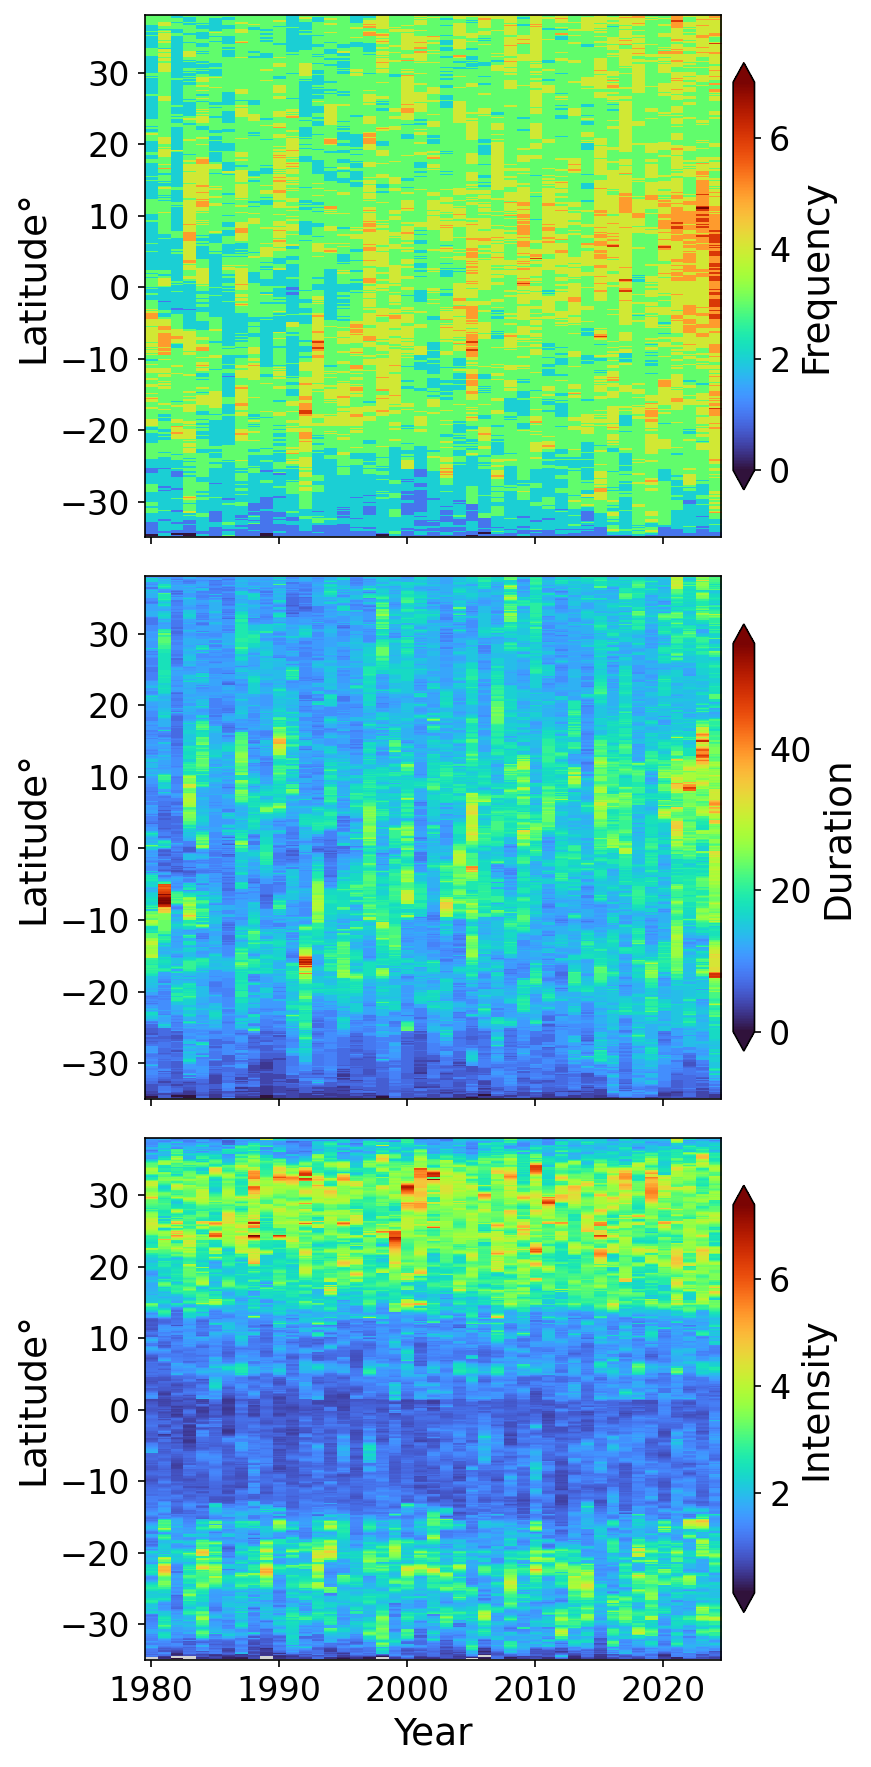


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_3x1_Frequency_Duration_Intensity.png


In [41]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
    "font.size": 14,        # base font
    "axes.labelsize": 18,   # x/y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
    "figure.titlesize": 16,
})

# ============================================================
# PATHS
# ============================================================
BASE = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max"
OUT_PNG = os.path.join(BASE, "hovmoller_3x1_Frequency_Duration_Intensity.png")

DIRS = {
    "Frequency": os.path.join(BASE, "00_Frequency"),
    "Duration":  os.path.join(BASE, "01_Duration"),
    "Intensity": os.path.join(BASE, "02_Intensity"),
}

# Color scaling
SCALE = {
    "Frequency": {"use_percentile": False, "plow": 2, "phigh": 98},
    "Duration":  {"use_percentile": False, "plow": 2, "phigh": 98},
    "Intensity": {"use_percentile": False, "plow": 2, "phigh": 98},
}

CMAP_NAME = "turbo"
INTERP = "nearest"
OVERRIDE_NODATA = None

FIGSIZE = (6, 12)
DPI_SHOW = 150
DPI_SAVE = 400

# ============================================================
# HELPERS
# ============================================================
def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

def list_year_tifs(folder):
    tifs = sorted(glob.glob(os.path.join(folder, "*.tif")) + glob.glob(os.path.join(folder, "*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No GeoTIFFs found in: {folder}")
    pairs = [(extract_year(fp), fp) for fp in tifs]
    pairs.sort(key=lambda x: x[0])
    years = np.array([p[0] for p in pairs], dtype=int)
    files = [p[1] for p in pairs]
    return years, files

def build_hovmoller(files, grid_ref=None):
    with rasterio.open(files[0]) as src0:
        transform = src0.transform
        crs = src0.crs
        height, width = src0.height, src0.width

    if grid_ref is not None:
        if (height != grid_ref["height"] or width != grid_ref["width"] or
            transform != grid_ref["transform"] or crs != grid_ref["crs"]):
            raise ValueError("Grid mismatch between variables (Frequency/Duration/Intensity).")

    y0 = transform.f
    e = transform.e
    y_coords = y0 + e * (np.arange(height) + 0.5)

    H = np.full((len(files), height), np.nan, dtype=np.float32)

    for i, fp in enumerate(files):
        with rasterio.open(fp) as src:
            if (src.height != height or src.width != width or
                src.transform != transform or src.crs != crs):
                raise ValueError(f"Grid mismatch within folder at:\n{fp}")

            arr = src.read(1).astype(np.float32)
            nd = OVERRIDE_NODATA if OVERRIDE_NODATA is not None else src.nodata
            if nd is not None:
                arr = np.where(arr == nd, np.nan, arr)

        H[i, :] = np.nanmax(arr, axis=1)

    if y_coords[0] > y_coords[-1]:
        y_coords = y_coords[::-1]
        H = H[:, ::-1]

    return y_coords, H, crs, transform, height, width

def get_vmin_vmax(H, use_percentile, plow, phigh):
    vals = H[np.isfinite(H)]
    if vals.size == 0:
        raise ValueError("All values became NaN. Check nodata handling.")
    if use_percentile:
        return np.percentile(vals, [plow, phigh])
    return float(np.min(vals)), float(np.max(vals))

# ============================================================
# LOAD ALL THREE
# ============================================================
data = {}
years_common = None
grid_ref = None
y_coords = None

for name, folder in DIRS.items():
    years, files = list_year_tifs(folder)

    if years_common is None:
        years_common = years
    else:
        if not np.array_equal(years_common, years):
            raise ValueError(f"Years mismatch for {name}. Make sure all folders have the same years/files.")

    y_coords, H, crs, transform, height, width = build_hovmoller(files, grid_ref=grid_ref)

    if grid_ref is None:
        grid_ref = {"height": height, "width": width, "transform": transform, "crs": crs}

    sc = SCALE[name]
    vmin, vmax = get_vmin_vmax(H, sc["use_percentile"], sc["plow"], sc["phigh"])
    data[name] = dict(H=H, vmin=vmin, vmax=vmax)

extent = [years_common.min() - 0.5, years_common.max() + 0.5, y_coords.min(), y_coords.max()]

# ============================================================
# PLOT 3x1 (NO TITLES)
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=FIGSIZE, dpi=DPI_SHOW, sharex=True, sharey=True)

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

for ax, name in zip(axes, ["Frequency", "Duration", "Intensity"]):
    H = data[name]["H"]
    vmin = data[name]["vmin"]
    vmax = data[name]["vmax"]

    im = ax.imshow(
        H.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation=INTERP
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, extend="both")
    cbar.set_label(name, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

axes[-1].set_xlabel("Year")

ylabel = "Latitude°" if (grid_ref["crs"] and grid_ref["crs"].is_geographic) else "Y (northing / row coord)"
for ax in axes:
    ax.set_ylabel(ylabel)

# ---- Y-ticks every 10 (for latitude) ----
# If your CRS is projected (meters), "10" means 10 meters (too dense).
# In that case, change 10 to something like 100000, etc.
for ax in axes:
    ax.yaxis.set_major_locator(MultipleLocator(10))

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=DPI_SAVE)
plt.show()

print(f"\nSaved: {OUT_PNG}")


C:\Users\maharjan\AppData\Local\Temp\ipykernel_38172\42365651.py:98: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=1)


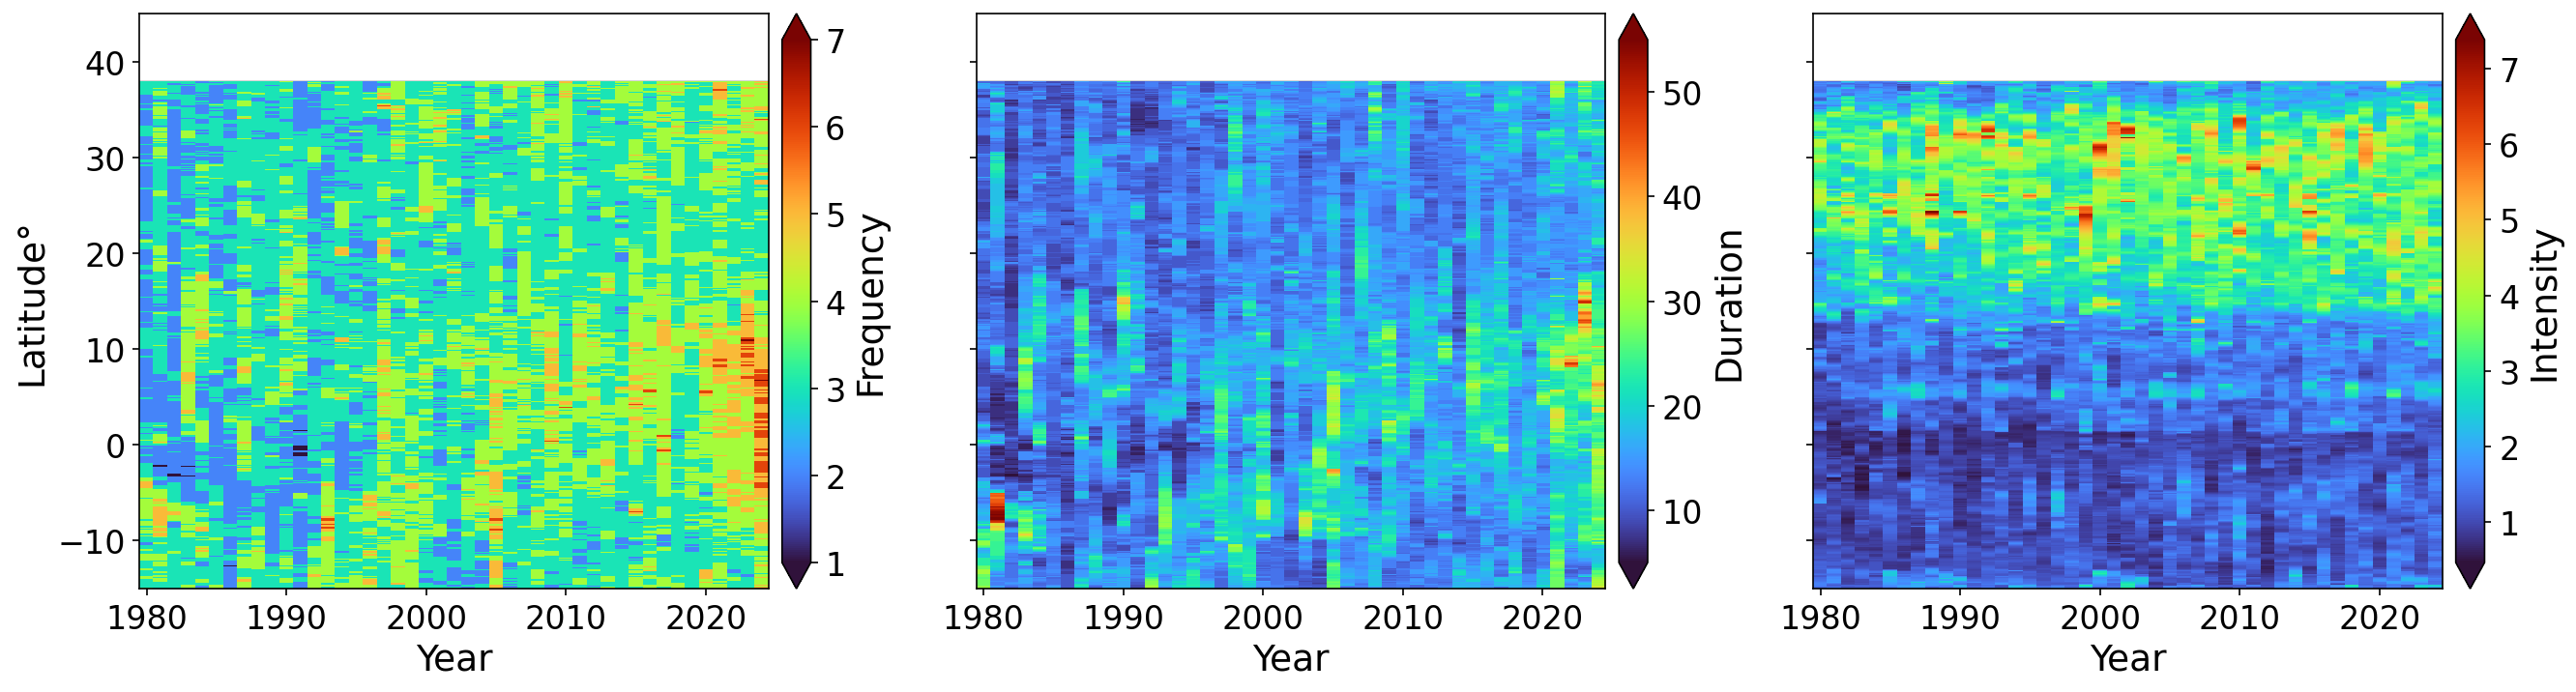


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_1x3_LAT_Frequency_Duration_Intensity_lat_-15_50.png


In [7]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.titlesize": 16,
})

# ============================================================
# PATHS
# ============================================================
BASE = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max"
OUT_PNG = os.path.join(BASE, "hovmoller_1x3_LAT_Frequency_Duration_Intensity_lat_-15_50.png")

DIRS = {
    "Frequency": os.path.join(BASE, "00_Frequency"),
    "Duration":  os.path.join(BASE, "01_Duration"),
    "Intensity": os.path.join(BASE, "02_Intensity"),
}

# Color scaling
SCALE = {
    "Frequency": {"use_percentile": False, "plow": 2, "phigh": 98},
    "Duration":  {"use_percentile": False, "plow": 2, "phigh": 98},
    "Intensity": {"use_percentile": False, "plow": 2, "phigh": 98},
}

CMAP_NAME = "turbo"
INTERP = "nearest"
OVERRIDE_NODATA = None

# 1 row x 3 col
FIGSIZE = (18, 5)
DPI_SHOW = 150
DPI_SAVE = 400

# Latitude range you want
LAT_MIN, LAT_MAX = -15, 45

# ============================================================
# HELPERS
# ============================================================
def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

def list_year_tifs(folder):
    tifs = sorted(glob.glob(os.path.join(folder, "*.tif")) + glob.glob(os.path.join(folder, "*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No GeoTIFFs found in: {folder}")
    pairs = [(extract_year(fp), fp) for fp in tifs]
    pairs.sort(key=lambda x: x[0])
    years = np.array([p[0] for p in pairs], dtype=int)
    files = [p[1] for p in pairs]
    return years, files

def build_hovmoller_lat(files, grid_ref=None):
    """Return y_coords (lat), H(year, y) using nanmax across longitude."""
    with rasterio.open(files[0]) as src0:
        transform = src0.transform
        crs = src0.crs
        height, width = src0.height, src0.width

    if grid_ref is not None:
        if (height != grid_ref["height"] or width != grid_ref["width"] or
            transform != grid_ref["transform"] or crs != grid_ref["crs"]):
            raise ValueError("Grid mismatch between variables (Frequency/Duration/Intensity).")

    y0 = transform.f
    e = transform.e
    y_coords = y0 + e * (np.arange(height) + 0.5)

    H = np.full((len(files), height), np.nan, dtype=np.float32)

    for i, fp in enumerate(files):
        with rasterio.open(fp) as src:
            if (src.height != height or src.width != width or
                src.transform != transform or src.crs != crs):
                raise ValueError(f"Grid mismatch within folder at:\n{fp}")

            arr = src.read(1).astype(np.float32)
            nd = OVERRIDE_NODATA if OVERRIDE_NODATA is not None else src.nodata
            if nd is not None:
                arr = np.where(arr == nd, np.nan, arr)

        # collapse longitude -> keep latitude profile
        H[i, :] = np.nanmax(arr, axis=1)

    # ensure y increasing
    if y_coords[0] > y_coords[-1]:
        y_coords = y_coords[::-1]
        H = H[:, ::-1]

    return y_coords, H, crs, transform, height, width

def get_vmin_vmax(H, use_percentile, plow, phigh):
    vals = H[np.isfinite(H)]
    if vals.size == 0:
        raise ValueError("All values became NaN. Check nodata handling.")
    if use_percentile:
        vmin, vmax = np.percentile(vals, [plow, phigh])
        return float(vmin), float(vmax)
    return float(np.min(vals)), float(np.max(vals))

def subset_lat(y_coords, H, lat_min, lat_max):
    """Subset H to requested latitude range."""
    lo, hi = (lat_min, lat_max) if lat_min <= lat_max else (lat_max, lat_min)
    mask = (y_coords >= lo) & (y_coords <= hi)
    if not np.any(mask):
        raise ValueError(
            f"No latitude values found in range [{lo}, {hi}]. "
            f"Available range is [{y_coords.min():.3f}, {y_coords.max():.3f}]"
        )
    return y_coords[mask], H[:, mask]

# ============================================================
# LOAD ALL THREE
# ============================================================
data = {}
years_common = None
grid_ref = None
y_coords_common = None

for name, folder in DIRS.items():
    years, files = list_year_tifs(folder)

    if years_common is None:
        years_common = years
    else:
        if not np.array_equal(years_common, years):
            raise ValueError(f"Years mismatch for {name}. Make sure all folders have the same years/files.")

    y_coords, H, crs, transform, height, width = build_hovmoller_lat(files, grid_ref=grid_ref)

    if grid_ref is None:
        grid_ref = {"height": height, "width": width, "transform": transform, "crs": crs}

    # subset to lat range -15 to 50
    y_sub, H_sub = subset_lat(y_coords, H, LAT_MIN, LAT_MAX)

    if y_coords_common is None:
        y_coords_common = y_sub
    else:
        if not np.allclose(y_coords_common, y_sub):
            raise ValueError("Latitude coordinates mismatch after subsetting. Check rasters alignment.")

    sc = SCALE[name]
    vmin, vmax = get_vmin_vmax(H_sub, sc["use_percentile"], sc["plow"], sc["phigh"])
    data[name] = dict(H=H_sub, vmin=vmin, vmax=vmax)

extent = [years_common.min() - 0.5, years_common.max() + 0.5, y_coords_common.min(), y_coords_common.max()]

# ============================================================
# PLOT 1x3 (NO TITLES)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, dpi=DPI_SHOW, sharex=True, sharey=True)

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

for ax, name in zip(axes, ["Frequency", "Duration", "Intensity"]):
    H = data[name]["H"]
    vmin = data[name]["vmin"]
    vmax = data[name]["vmax"]

    im = ax.imshow(
        H.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation=INTERP
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, extend="both")
    cbar.set_label(name, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    ax.set_xlabel("Year")

# Y label only on first subplot
ylabel = "Latitude°" if (grid_ref["crs"] and grid_ref["crs"].is_geographic) else "Y (northing / row coord)"
axes[0].set_ylabel(ylabel)

# ticks every 10 degrees
if grid_ref["crs"] and grid_ref["crs"].is_geographic:
    for ax in axes:
        ax.yaxis.set_major_locator(MultipleLocator(10))

# force y-limits exactly -15 to 50
for ax in axes:
    ax.set_ylim(LAT_MIN, LAT_MAX)

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=DPI_SAVE)
plt.show()

print(f"\nSaved: {OUT_PNG}")


In [9]:
import rasterio, numpy as np

fp = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\00_Frequency\1980_max.tif"

with rasterio.open(fp) as src:
    arr = src.read(1, masked=True).astype(np.float32)
    a = np.where(arr.mask, np.nan, arr.data)

print("nodata:", src.nodata)
print("min/max:", np.nanmin(a), np.nanmax(a))
print("finite count:", np.isfinite(a).sum(), " / total:", a.size)


nodata: nan
min/max: 0.0 5.0
finite count: 378507  / total: 770858


In [10]:
import numpy as np

row_valid = np.isfinite(a).sum(axis=1)          # how many valid pixels per latitude row
row_max   = np.nanmax(a, axis=1)                # what you're using
row_p95   = np.nanpercentile(a, 95, axis=1)     # more robust
row_p99   = np.nanpercentile(a, 99, axis=1)

# Find suspicious rows: very few valid pixels but high max
sus = np.where((row_valid < 50) & (row_max >= 4.5))[0]   # tweak thresholds if needed

print("Number of suspicious rows:", len(sus))
print("First 15 suspicious rows:", sus[:15])

# Print details for a few rows
for r in sus[:10]:
    print(f"row={r} valid={row_valid[r]} max={row_max[r]:.2f} p95={row_p95[r]:.2f} p99={row_p99[r]:.2f}")


Number of suspicious rows: 0
First 15 suspicious rows: []


C:\Users\maharjan\AppData\Local\Temp\ipykernel_38172\1185921398.py:4: RuntimeWarning: All-NaN slice encountered
  row_max   = np.nanmax(a, axis=1)                # what you're using
c:\ProgramData\anaconda3\envs\emit\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [11]:
row_valid = np.isfinite(a).sum(axis=1)
all_nan_rows = np.where(row_valid == 0)[0]

print("All-NaN rows:", len(all_nan_rows))
print("First 20 all-NaN rows:", all_nan_rows[:20])
print("Row index range:", all_nan_rows.min(), all_nan_rows.max())


All-NaN rows: 3
First 20 all-NaN rows: [  0 812 813]
Row index range: 0 813


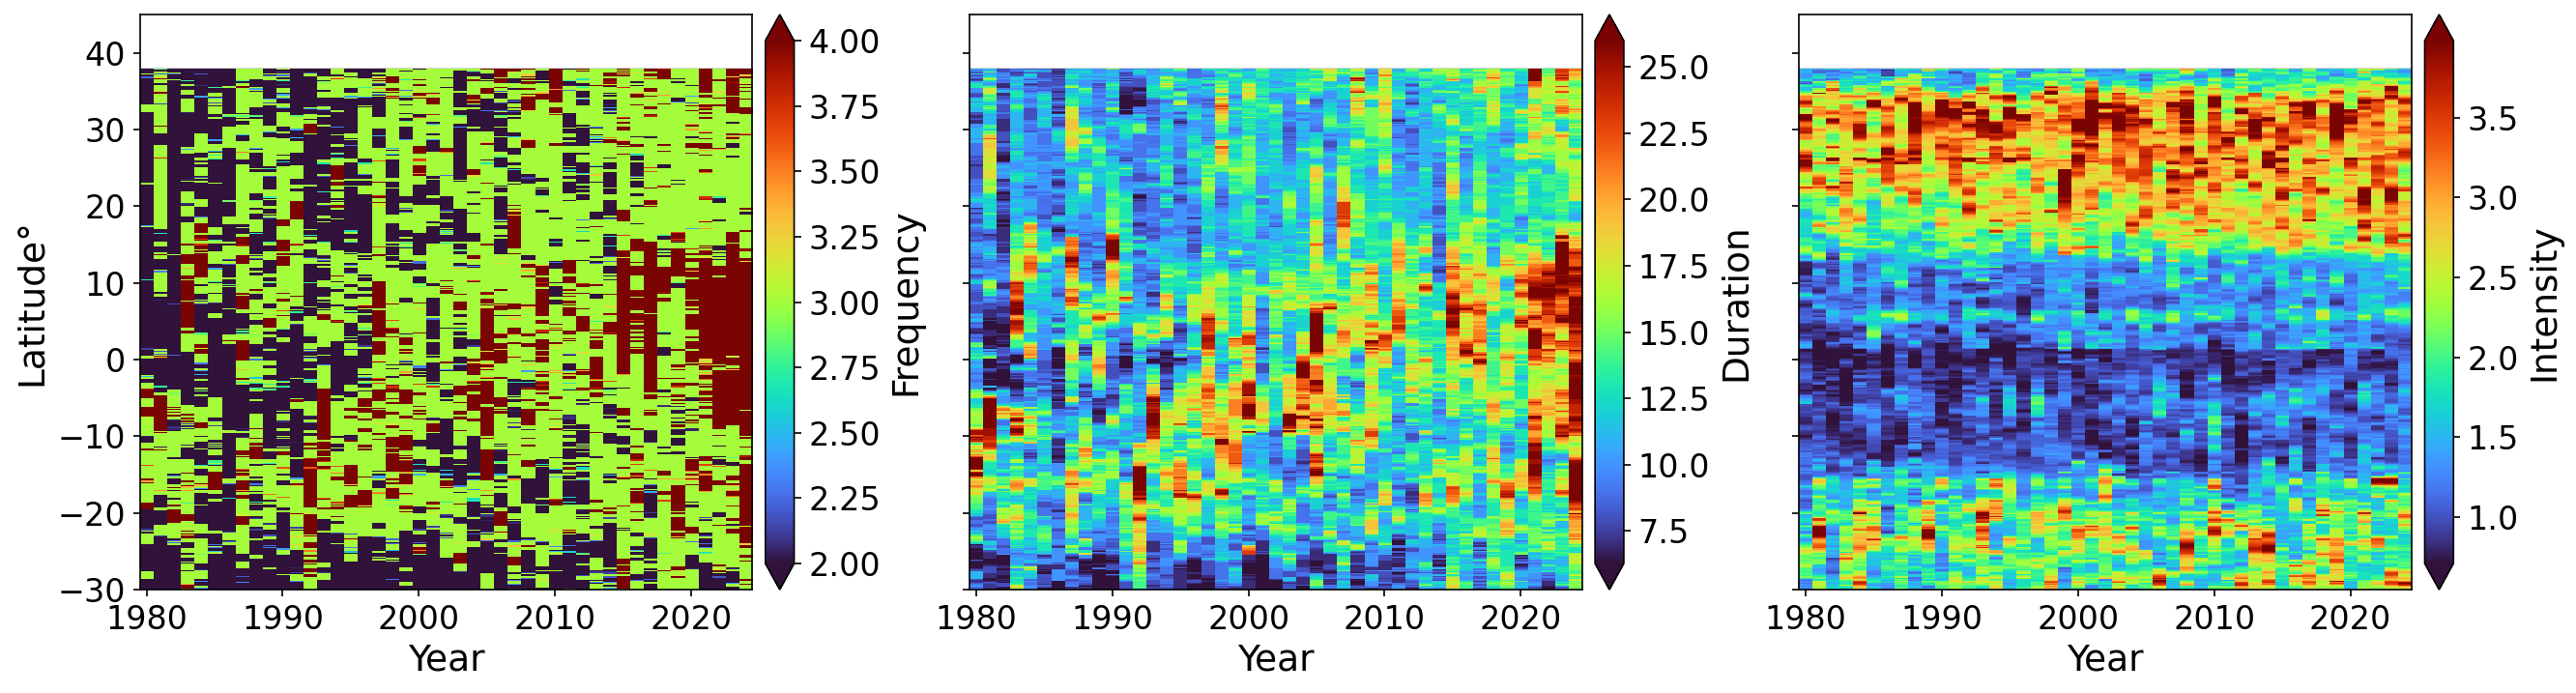


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_1x3_LAT_Frequency_Duration_Intensity_lat_-15_45_P99.png


In [14]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.titlesize": 16,
})

# ============================================================
# PATHS
# ============================================================
BASE = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max"
OUT_PNG = os.path.join(BASE, "hovmoller_1x3_LAT_Frequency_Duration_Intensity_lat_-15_45_P99.png")

DIRS = {
    "Frequency": os.path.join(BASE, "00_Frequency"),
    "Duration":  os.path.join(BASE, "01_Duration"),
    "Intensity": os.path.join(BASE, "02_Intensity"),
}

# Color scaling
SCALE = {
    "Frequency": {"use_percentile": True, "plow": 2, "phigh": 98},
    "Duration":  {"use_percentile": True, "plow": 2, "phigh": 98},
    "Intensity": {"use_percentile": True, "plow": 2, "phigh": 98},
}

CMAP_NAME = "turbo"
INTERP = "nearest"

# 1 row x 3 col
FIGSIZE = (18, 5)
DPI_SHOW = 150
DPI_SAVE = 400

# Latitude range you want
LAT_MIN, LAT_MAX = -30, 45

# Robust longitude-collapse percentile (fixes brown strip from nanmax)
LON_COLLAPSE_PCT = 99  # try 95 if you want less extreme

# ============================================================
# HELPERS
# ============================================================
def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

def list_year_tifs(folder):
    tifs = sorted(glob.glob(os.path.join(folder, "*.tif")) + glob.glob(os.path.join(folder, "*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No GeoTIFFs found in: {folder}")
    pairs = [(extract_year(fp), fp) for fp in tifs]
    pairs.sort(key=lambda x: x[0])
    years = np.array([p[0] for p in pairs], dtype=int)
    files = [p[1] for p in pairs]
    return years, files

def build_hovmoller_lat(files, grid_ref=None):
    """
    Return y_coords (lat), H(year, y) using a ROBUST "max-like" statistic
    across longitude: nanpercentile(arr, LON_COLLAPSE_PCT, axis=1).

    This avoids brown strips caused by nanmax picking 1–2 extreme pixels.
    """
    with rasterio.open(files[0]) as src0:
        transform = src0.transform
        crs = src0.crs
        height, width = src0.height, src0.width

    if grid_ref is not None:
        if (height != grid_ref["height"] or width != grid_ref["width"] or
            transform != grid_ref["transform"] or crs != grid_ref["crs"]):
            raise ValueError("Grid mismatch between variables (Frequency/Duration/Intensity).")

    # Y coordinates from affine transform (pixel centers)
    y0 = transform.f
    e = transform.e
    y_coords = y0 + e * (np.arange(height) + 0.5)

    H = np.full((len(files), height), np.nan, dtype=np.float32)

    for i, fp in enumerate(files):
        with rasterio.open(fp) as src:
            if (src.height != height or src.width != width or
                src.transform != transform or src.crs != crs):
                raise ValueError(f"Grid mismatch within folder at:\n{fp}")

            # robust nodata handling
            arrm = src.read(1, masked=True).astype(np.float32)
            arr = np.where(arrm.mask, np.nan, arrm.data)

        # ---- robust collapse across longitude (axis=1 is columns/lon) ----
        # Avoid warnings when a whole row is NaN by computing only for rows with data
        row_valid = np.isfinite(arr).sum(axis=1)
        prof = np.full(height, np.nan, dtype=np.float32)

        good = row_valid > 0
        if np.any(good):
            prof[good] = np.nanpercentile(arr[good, :], LON_COLLAPSE_PCT, axis=1).astype(np.float32)

        H[i, :] = prof

    # ensure y increasing
    if y_coords[0] > y_coords[-1]:
        y_coords = y_coords[::-1]
        H = H[:, ::-1]

    return y_coords, H, crs, transform, height, width

def get_vmin_vmax(H, use_percentile, plow, phigh):
    vals = H[np.isfinite(H)]
    if vals.size == 0:
        raise ValueError("All values became NaN. Check nodata/mask handling.")
    if use_percentile:
        vmin, vmax = np.percentile(vals, [plow, phigh])
        return float(vmin), float(vmax)
    return float(np.min(vals)), float(np.max(vals))

def subset_lat(y_coords, H, lat_min, lat_max):
    lo, hi = (lat_min, lat_max) if lat_min <= lat_max else (lat_max, lat_min)
    mask = (y_coords >= lo) & (y_coords <= hi)
    if not np.any(mask):
        raise ValueError(
            f"No latitude values found in range [{lo}, {hi}]. "
            f"Available range is [{y_coords.min():.3f}, {y_coords.max():.3f}]"
        )
    return y_coords[mask], H[:, mask]

# ============================================================
# LOAD ALL THREE
# ============================================================
data = {}
years_common = None
grid_ref = None
y_coords_common = None

for name, folder in DIRS.items():
    years, files = list_year_tifs(folder)

    if years_common is None:
        years_common = years
    else:
        if not np.array_equal(years_common, years):
            raise ValueError(f"Years mismatch for {name}. Make sure all folders have the same years/files.")

    y_coords, H, crs, transform, height, width = build_hovmoller_lat(files, grid_ref=grid_ref)

    if grid_ref is None:
        grid_ref = {"height": height, "width": width, "transform": transform, "crs": crs}

    # subset latitude
    y_sub, H_sub = subset_lat(y_coords, H, LAT_MIN, LAT_MAX)

    if y_coords_common is None:
        y_coords_common = y_sub
    else:
        if not np.allclose(y_coords_common, y_sub):
            raise ValueError("Latitude coordinates mismatch after subsetting. Check rasters alignment.")

    sc = SCALE[name]
    vmin, vmax = get_vmin_vmax(H_sub, sc["use_percentile"], sc["plow"], sc["phigh"])
    data[name] = dict(H=H_sub, vmin=vmin, vmax=vmax)

extent = [years_common.min() - 0.5, years_common.max() + 0.5, y_coords_common.min(), y_coords_common.max()]

# ============================================================
# PLOT 1x3 (NO TITLES)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, dpi=DPI_SHOW, sharex=True, sharey=True)

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")  # masked/NaN color

for ax, name in zip(axes, ["Frequency", "Duration", "Intensity"]):
    H = data[name]["H"]
    vmin = data[name]["vmin"]
    vmax = data[name]["vmax"]

    im = ax.imshow(
        H.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation=INTERP
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, extend="both")
    cbar.set_label(name, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    ax.set_xlabel("Year")

# Y label only on first subplot
ylabel = "Latitude°" if (grid_ref["crs"] and grid_ref["crs"].is_geographic) else "Y (northing / row coord)"
axes[0].set_ylabel(ylabel)

# ticks every 10 degrees (if geographic)
if grid_ref["crs"] and grid_ref["crs"].is_geographic:
    for ax in axes:
        ax.yaxis.set_major_locator(MultipleLocator(10))

# force y-limits exactly
for ax in axes:
    ax.set_ylim(LAT_MIN, LAT_MAX)

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=DPI_SAVE)
plt.show()

print(f"\nSaved: {OUT_PNG}")


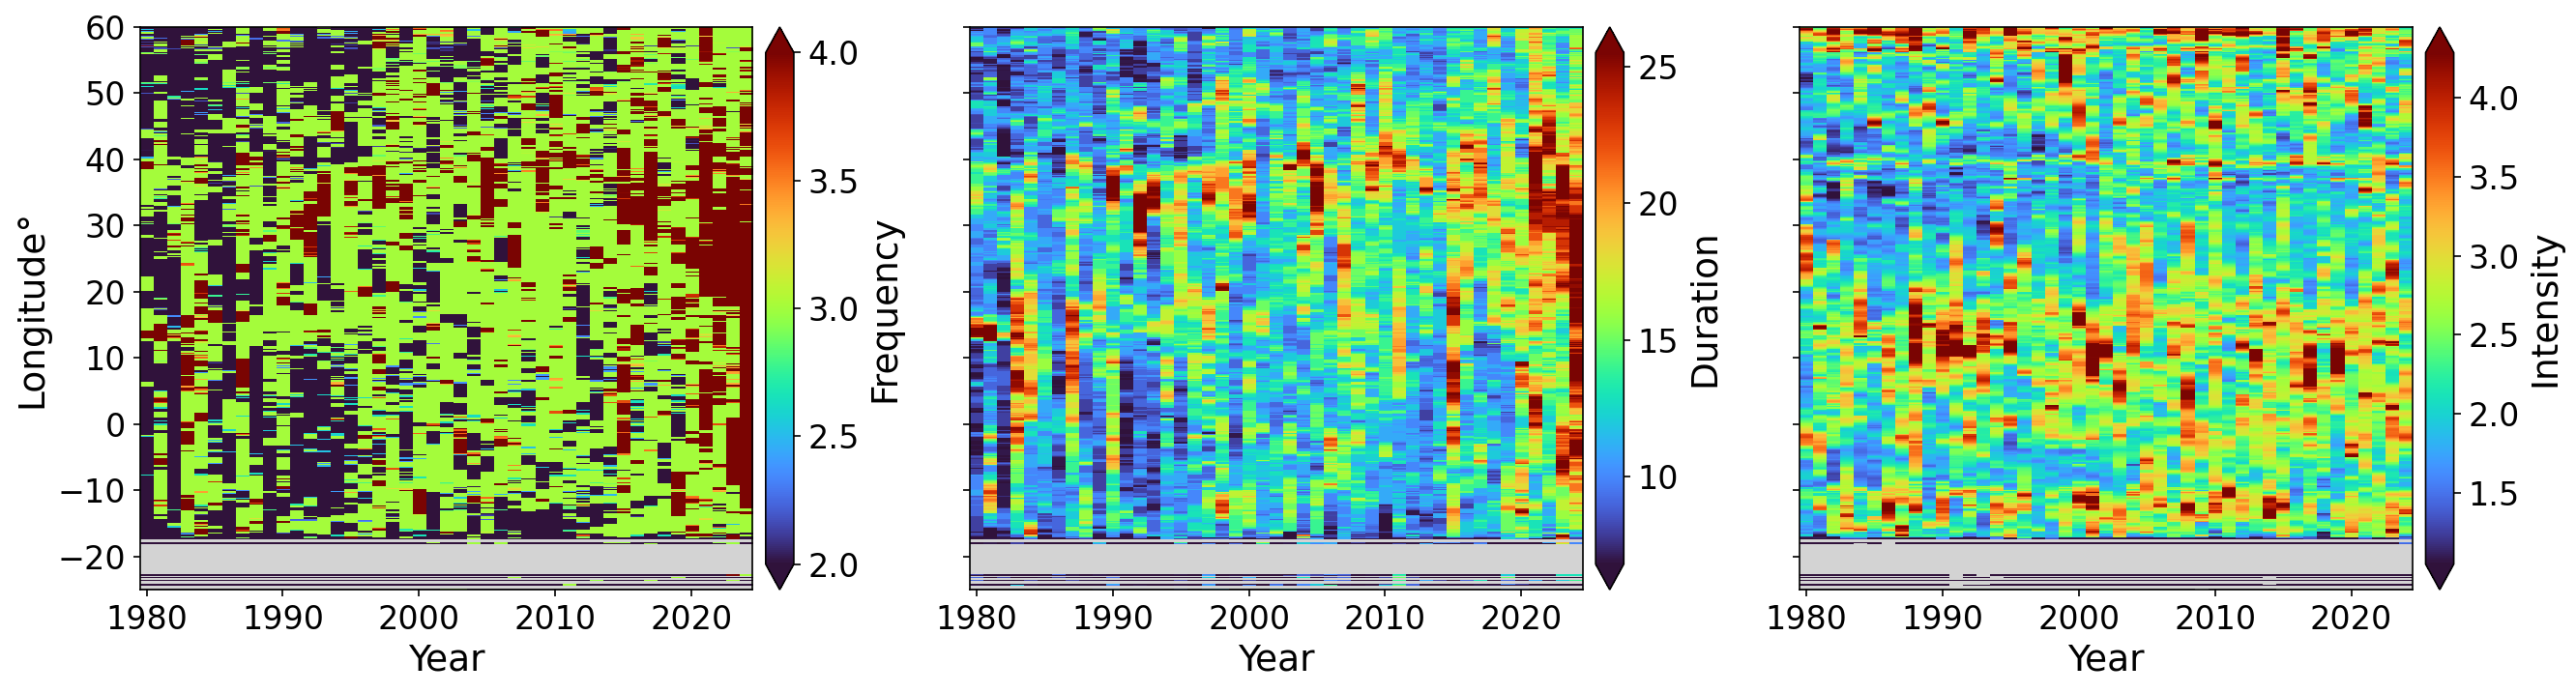


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_1x3_LON_Frequency_Duration_Intensity_lon_80_90_P99.png


In [16]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.titlesize": 16,
})

# ============================================================
# PATHS
# ============================================================
BASE = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max"
OUT_PNG = os.path.join(BASE, "hovmoller_1x3_LON_Frequency_Duration_Intensity_lon_80_90_P99.png")

DIRS = {
    "Frequency": os.path.join(BASE, "00_Frequency"),
    "Duration":  os.path.join(BASE, "01_Duration"),
    "Intensity": os.path.join(BASE, "02_Intensity"),
}

# Color scaling
SCALE = {
    "Frequency": {"use_percentile": True, "plow": 2, "phigh": 98},
    "Duration":  {"use_percentile": True, "plow": 2, "phigh": 98},
    "Intensity": {"use_percentile": True, "plow": 2, "phigh": 98},
}

CMAP_NAME = "turbo"
INTERP = "nearest"

# 1 row x 3 col
FIGSIZE = (18, 5)
DPI_SHOW = 150
DPI_SAVE = 400

# Longitude range you want
LON_MIN, LON_MAX = -25, 60

# Robust latitude-collapse percentile (fixes strip from nanmax)
LAT_COLLAPSE_PCT = 99  # try 95 if you want less extreme

# ============================================================
# HELPERS
# ============================================================
def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

def list_year_tifs(folder):
    tifs = sorted(glob.glob(os.path.join(folder, "*.tif")) + glob.glob(os.path.join(folder, "*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No GeoTIFFs found in: {folder}")
    pairs = [(extract_year(fp), fp) for fp in tifs]
    pairs.sort(key=lambda x: x[0])
    years = np.array([p[0] for p in pairs], dtype=int)
    files = [p[1] for p in pairs]
    return years, files

def build_hovmoller_lon(files, grid_ref=None):
    """
    Return x_coords (lon), H(year, x) using a ROBUST "max-like" statistic
    across latitude: nanpercentile(arr, LAT_COLLAPSE_PCT, axis=0).

    axis=0 collapses rows (latitude), keeping columns (longitude).
    """
    with rasterio.open(files[0]) as src0:
        transform = src0.transform
        crs = src0.crs
        height, width = src0.height, src0.width

    if grid_ref is not None:
        if (height != grid_ref["height"] or width != grid_ref["width"] or
            transform != grid_ref["transform"] or crs != grid_ref["crs"]):
            raise ValueError("Grid mismatch between variables (Frequency/Duration/Intensity).")

    # X coordinates from affine transform (pixel centers)
    x0 = transform.c
    a = transform.a
    x_coords = x0 + a * (np.arange(width) + 0.5)

    H = np.full((len(files), width), np.nan, dtype=np.float32)

    for i, fp in enumerate(files):
        with rasterio.open(fp) as src:
            if (src.height != height or src.width != width or
                src.transform != transform or src.crs != crs):
                raise ValueError(f"Grid mismatch within folder at:\n{fp}")

            arrm = src.read(1, masked=True).astype(np.float32)
            arr = np.where(arrm.mask, np.nan, arrm.data)

        # ---- robust collapse across latitude (axis=0 is rows/lat) ----
        col_valid = np.isfinite(arr).sum(axis=0)
        prof = np.full(width, np.nan, dtype=np.float32)

        good = col_valid > 0
        if np.any(good):
            prof[good] = np.nanpercentile(arr[:, good], LAT_COLLAPSE_PCT, axis=0).astype(np.float32)

        H[i, :] = prof

    # ensure x increasing
    if x_coords[0] > x_coords[-1]:
        x_coords = x_coords[::-1]
        H = H[:, ::-1]

    return x_coords, H, crs, transform, height, width

def get_vmin_vmax(H, use_percentile, plow, phigh):
    vals = H[np.isfinite(H)]
    if vals.size == 0:
        raise ValueError("All values became NaN. Check nodata/mask handling.")
    if use_percentile:
        vmin, vmax = np.percentile(vals, [plow, phigh])
        return float(vmin), float(vmax)
    return float(np.min(vals)), float(np.max(vals))

def subset_lon(x_coords, H, lon_min, lon_max):
    lo, hi = (lon_min, lon_max) if lon_min <= lon_max else (lon_max, lon_min)
    mask = (x_coords >= lo) & (x_coords <= hi)
    if not np.any(mask):
        raise ValueError(
            f"No longitude values found in range [{lo}, {hi}]. "
            f"Available range is [{x_coords.min():.3f}, {x_coords.max():.3f}]"
        )
    return x_coords[mask], H[:, mask]

# ============================================================
# LOAD ALL THREE
# ============================================================
data = {}
years_common = None
grid_ref = None
x_coords_common = None

for name, folder in DIRS.items():
    years, files = list_year_tifs(folder)

    if years_common is None:
        years_common = years
    else:
        if not np.array_equal(years_common, years):
            raise ValueError(f"Years mismatch for {name}. Make sure all folders have the same years/files.")

    x_coords, H, crs, transform, height, width = build_hovmoller_lon(files, grid_ref=grid_ref)

    if grid_ref is None:
        grid_ref = {"height": height, "width": width, "transform": transform, "crs": crs}

    # subset longitude
    x_sub, H_sub = subset_lon(x_coords, H, LON_MIN, LON_MAX)

    if x_coords_common is None:
        x_coords_common = x_sub
    else:
        if not np.allclose(x_coords_common, x_sub):
            raise ValueError("Longitude coordinates mismatch after subsetting. Check rasters alignment.")

    sc = SCALE[name]
    vmin, vmax = get_vmin_vmax(H_sub, sc["use_percentile"], sc["plow"], sc["phigh"])
    data[name] = dict(H=H_sub, vmin=vmin, vmax=vmax)

extent = [years_common.min() - 0.5, years_common.max() + 0.5, x_coords_common.min(), x_coords_common.max()]

# ============================================================
# PLOT 1x3 (NO TITLES)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, dpi=DPI_SHOW, sharex=True, sharey=True)

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")  # masked/NaN color

for ax, name in zip(axes, ["Frequency", "Duration", "Intensity"]):
    H = data[name]["H"]
    vmin = data[name]["vmin"]
    vmax = data[name]["vmax"]

    im = ax.imshow(
        H.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation=INTERP
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, extend="both")
    cbar.set_label(name, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    ax.set_xlabel("Year")

# Y label only on first subplot (now Longitude)
ylabel = "Longitude°" if (grid_ref["crs"] and grid_ref["crs"].is_geographic) else "X (easting / col coord)"
axes[0].set_ylabel(ylabel)

# ticks every 10 degrees (if geographic)
if grid_ref["crs"] and grid_ref["crs"].is_geographic:
    for ax in axes:
        ax.yaxis.set_major_locator(MultipleLocator(10))

# force y-limits exactly (now longitude limits)
for ax in axes:
    ax.set_ylim(LON_MIN, LON_MAX)

fig.tight_layout()
#fig.savefig(OUT_PNG, dpi=DPI_SAVE)
plt.show()

print(f"\nSaved: {OUT_PNG}")


C:\Users\maharjan\AppData\Local\Temp\ipykernel_3655340\3694319913.py:101: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=0)


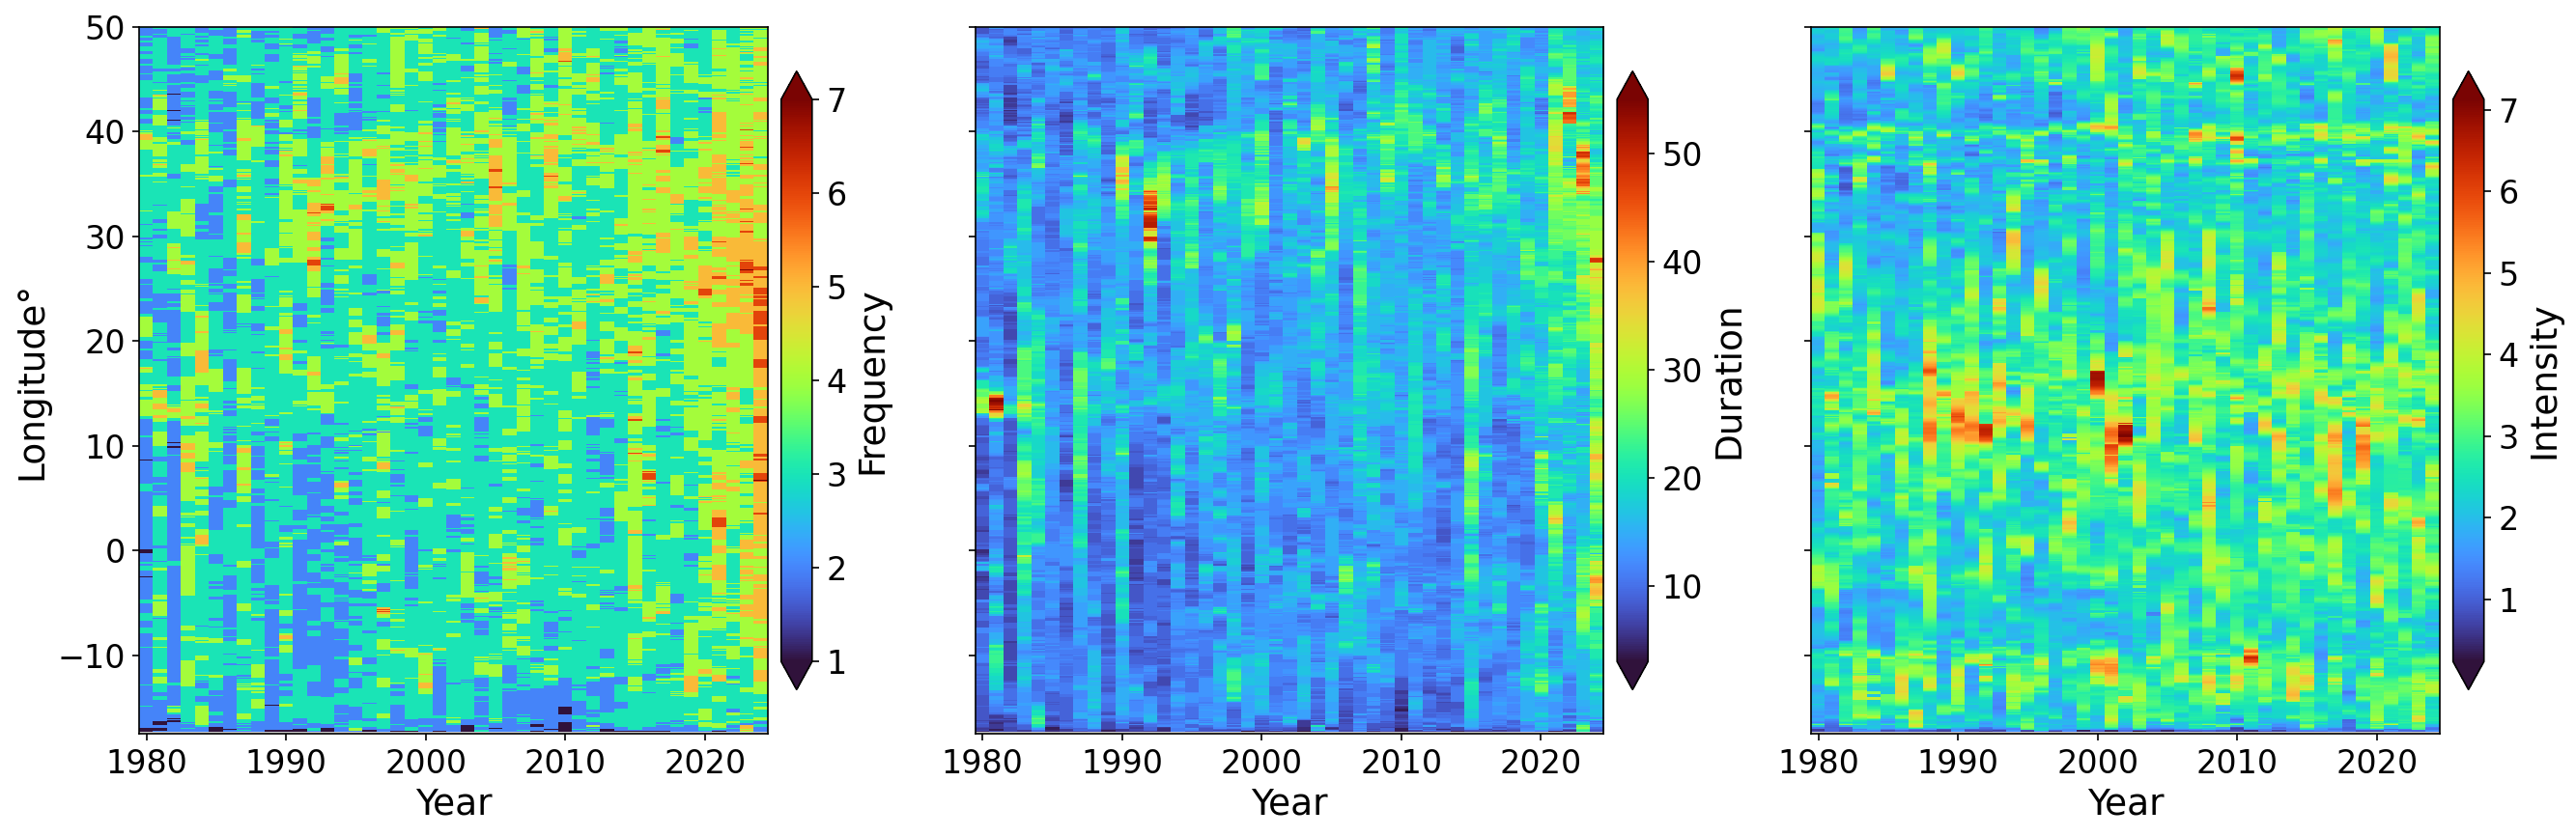


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_1x3_Frequency_Duration_Intensity_LONGITUDE.png


In [7]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams.update({
    "font.size": 14,        # base font
    "axes.labelsize": 18,   # x/y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
    "figure.titlesize": 16,
})

# ============================================================
# PATHS
# ============================================================
BASE = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max"
OUT_PNG = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_1x3_Frequency_Duration_Intensity_LONGITUDE.png"

DIRS = {
    "Frequency": os.path.join(BASE, "00_Frequency"),
    "Duration":  os.path.join(BASE, "01_Duration"),
    "Intensity": os.path.join(BASE, "02_Intensity"),
}

# Clip longitude range (degrees)
LON_MIN, LON_MAX = -17.5, 50.0

# Color scaling
SCALE = {
    "Frequency": {"use_percentile": False, "plow": 2, "phigh": 98},
    "Duration":  {"use_percentile": False, "plow": 2, "phigh": 98},
    "Intensity": {"use_percentile": False, "plow": 2, "phigh": 98},
}

CMAP_NAME = "turbo"
INTERP = "nearest"
OVERRIDE_NODATA = None

FIGSIZE = (18, 6)   # <-- wide for 1x3
DPI_SHOW = 150
DPI_SAVE = 400

# ============================================================
# HELPERS
# ============================================================
def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

def list_year_tifs(folder):
    tifs = sorted(glob.glob(os.path.join(folder, "*.tif")) + glob.glob(os.path.join(folder, "*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No GeoTIFFs found in: {folder}")
    pairs = [(extract_year(fp), fp) for fp in tifs]
    pairs.sort(key=lambda x: x[0])
    years = np.array([p[0] for p in pairs], dtype=int)
    files = [p[1] for p in pairs]
    return years, files

def build_hovmoller(files, grid_ref=None):
    """
    Build a Hovmöller with Y-axis = LONGITUDE.

    For each year raster:
      - collapse across rows (latitude) -> one value per column (longitude)
      - H shape = (n_years, width)
    """
    with rasterio.open(files[0]) as src0:
        transform = src0.transform
        crs = src0.crs
        height, width = src0.height, src0.width

    if grid_ref is not None:
        if (height != grid_ref["height"] or width != grid_ref["width"] or
            transform != grid_ref["transform"] or crs != grid_ref["crs"]):
            raise ValueError("Grid mismatch between variables (Frequency/Duration/Intensity).")

    # --- LONGITUDE / X coordinates ---
    x0 = transform.c  # x at upper-left corner
    a  = transform.a  # pixel width
    x_coords = x0 + a * (np.arange(width) + 0.5)

    H = np.full((len(files), width), np.nan, dtype=np.float32)

    for i, fp in enumerate(files):
        with rasterio.open(fp) as src:
            if (src.height != height or src.width != width or
                src.transform != transform or src.crs != crs):
                raise ValueError(f"Grid mismatch within folder at:\n{fp}")

            arr = src.read(1, masked=True).astype(np.float32)
            arr = np.where(arr.mask, np.nan, arr.data)

        H[i, :] = np.nanmax(arr, axis=0)

    if x_coords[0] > x_coords[-1]:
        x_coords = x_coords[::-1]
        H = H[:, ::-1]

    return x_coords, H, crs, transform, height, width

def get_vmin_vmax(H, use_percentile, plow, phigh):
    vals = H[np.isfinite(H)]
    if vals.size == 0:
        raise ValueError("All values became NaN. Check nodata handling.")
    if use_percentile:
        return np.percentile(vals, [plow, phigh])
    return float(np.min(vals)), float(np.max(vals))

# ============================================================
# LOAD ALL THREE
# ============================================================
data = {}
years_common = None
grid_ref = None
x_coords_final = None

for name, folder in DIRS.items():
    years, files = list_year_tifs(folder)

    if years_common is None:
        years_common = years
    else:
        if not np.array_equal(years_common, years):
            raise ValueError(f"Years mismatch for {name}. Make sure all folders have the same years/files.")

    x_coords, H, crs, transform, height, width = build_hovmoller(files, grid_ref=grid_ref)

    if grid_ref is None:
        grid_ref = {"height": height, "width": width, "transform": transform, "crs": crs}

    # Clip to longitude window (degrees)
    if not (crs and crs.is_geographic):
        raise ValueError("CRS is not geographic (lon/lat). Longitude clipping needs EPSG:4326-like CRS.")

    mask = (x_coords >= LON_MIN) & (x_coords <= LON_MAX)
    if mask.sum() == 0:
        raise ValueError(f"No columns found in longitude range [{LON_MIN}, {LON_MAX}]. Check CRS/extent.")
    x_coords = x_coords[mask]
    H = H[:, mask]

    sc = SCALE[name]
    vmin, vmax = get_vmin_vmax(H, sc["use_percentile"], sc["plow"], sc["phigh"])
    data[name] = dict(H=H, vmin=vmin, vmax=vmax)

    if x_coords_final is None:
        x_coords_final = x_coords
    else:
        if x_coords_final.shape != x_coords.shape or not np.allclose(x_coords_final, x_coords):
            raise ValueError("Longitude grid mismatch after clipping between variables.")

extent = [years_common.min() - 0.5, years_common.max() + 0.5, LON_MIN, LON_MAX]

# ============================================================
# PLOT 1x3 (NO TITLES)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, dpi=DPI_SHOW, sharex=True, sharey=True)

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

for ax, name in zip(axes, ["Frequency", "Duration", "Intensity"]):
    H = data[name]["H"]
    vmin = data[name]["vmin"]
    vmax = data[name]["vmax"]

    im = ax.imshow(
        H.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation=INTERP
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, extend="both")
    cbar.set_label(name, fontsize=18)
    cbar.ax.tick_params(labelsize=16)

    ax.set_xlabel("Year")

# Only left subplot gets y-label (cleaner)
axes[0].set_ylabel("Longitude°")

for ax in axes:
    ax.yaxis.set_major_locator(MultipleLocator(10))

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=DPI_SAVE)
plt.show()

print(f"\nSaved: {OUT_PNG}")

C:\Users\maharjan\AppData\Local\Temp\ipykernel_3655340\392318763.py:98: RuntimeWarning: All-NaN slice encountered
  H[i, :] = np.nanmax(arr, axis=0)


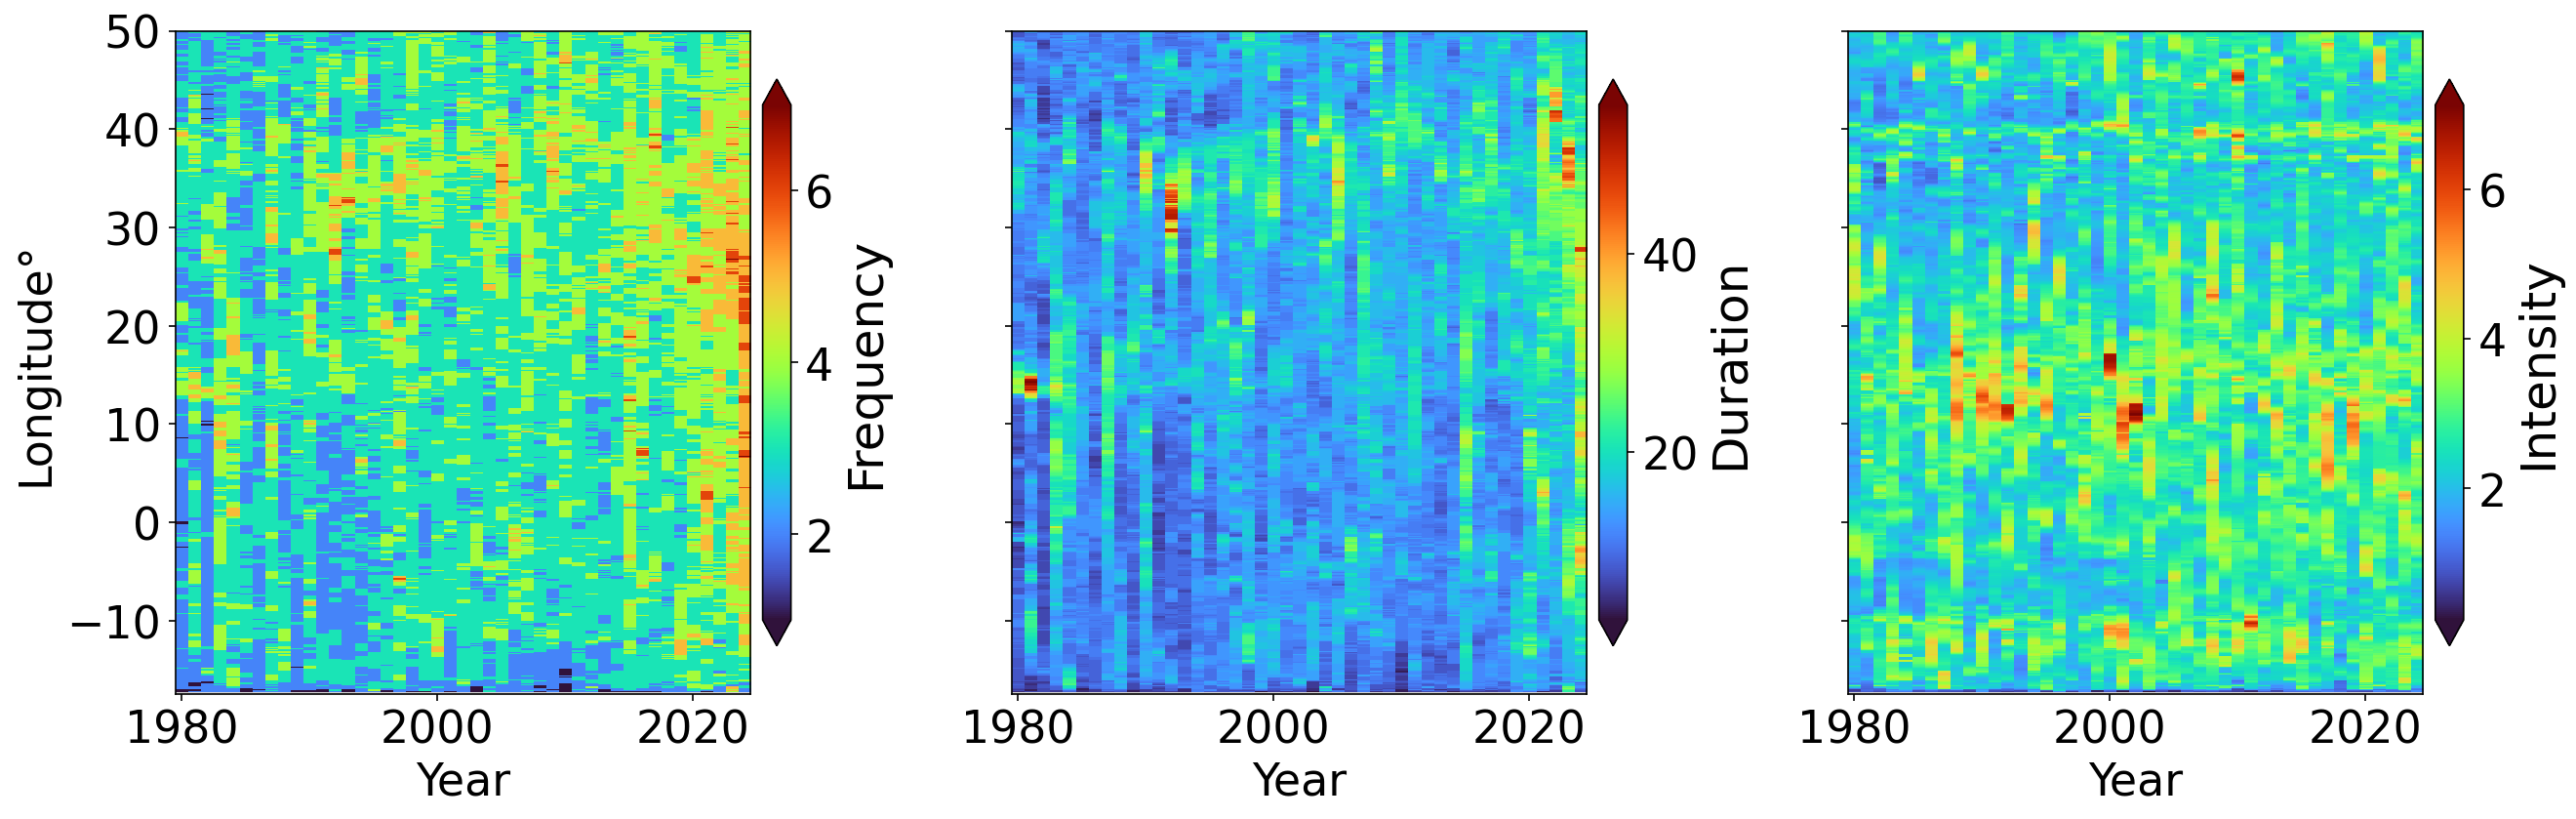


Saved: D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_1x3_Frequency_Duration_Intensity_LONGITUDE.png


In [9]:
import os
import re
import glob
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ============================================================
# BIGGER FONTS (GLOBAL)
# ============================================================
plt.rcParams.update({
    "font.size": 20,          # base
    "axes.labelsize": 22,     # x/y labels
    "axes.titlesize": 22,     # titles (if you add any)
    "xtick.labelsize": 22,    # x tick labels
    "ytick.labelsize": 22,    # y tick labels
    "legend.fontsize": 20,
    "figure.titlesize": 22,
})

# ============================================================
# PATHS
# ============================================================
BASE = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max"
OUT_PNG = r"D:\Thirst_Wave_Outputs\05_New_1980_2020_percentiles\05_Uploaded_GEE\03_Max\hovmoller_1x3_Frequency_Duration_Intensity_LONGITUDE.png"

DIRS = {
    "Frequency": os.path.join(BASE, "00_Frequency"),
    "Duration":  os.path.join(BASE, "01_Duration"),
    "Intensity": os.path.join(BASE, "02_Intensity"),
}

# Clip longitude range (degrees)
LON_MIN, LON_MAX = -17.5, 50.0

# Color scaling
SCALE = {
    "Frequency": {"use_percentile": False, "plow": 2, "phigh": 98},
    "Duration":  {"use_percentile": False, "plow": 2, "phigh": 98},
    "Intensity": {"use_percentile": False, "plow": 2, "phigh": 98},
}

CMAP_NAME = "turbo"
INTERP = "nearest"
OVERRIDE_NODATA = None

FIGSIZE = (18, 6)
DPI_SHOW = 150
DPI_SAVE = 400

# ============================================================
# HELPERS
# ============================================================
def extract_year(path):
    name = os.path.basename(path)
    m = re.search(r"(19\d{2}|20\d{2})", name)
    if not m:
        raise ValueError(f"Could not find a 4-digit year in filename: {name}")
    return int(m.group(1))

def list_year_tifs(folder):
    tifs = sorted(glob.glob(os.path.join(folder, "*.tif")) + glob.glob(os.path.join(folder, "*.tiff")))
    if not tifs:
        raise FileNotFoundError(f"No GeoTIFFs found in: {folder}")
    pairs = [(extract_year(fp), fp) for fp in tifs]
    pairs.sort(key=lambda x: x[0])
    years = np.array([p[0] for p in pairs], dtype=int)
    files = [p[1] for p in pairs]
    return years, files

def build_hovmoller(files, grid_ref=None):
    with rasterio.open(files[0]) as src0:
        transform = src0.transform
        crs = src0.crs
        height, width = src0.height, src0.width

    if grid_ref is not None:
        if (height != grid_ref["height"] or width != grid_ref["width"] or
            transform != grid_ref["transform"] or crs != grid_ref["crs"]):
            raise ValueError("Grid mismatch between variables (Frequency/Duration/Intensity).")

    x0 = transform.c
    a  = transform.a
    x_coords = x0 + a * (np.arange(width) + 0.5)

    H = np.full((len(files), width), np.nan, dtype=np.float32)

    for i, fp in enumerate(files):
        with rasterio.open(fp) as src:
            if (src.height != height or src.width != width or
                src.transform != transform or src.crs != crs):
                raise ValueError(f"Grid mismatch within folder at:\n{fp}")

            arr = src.read(1, masked=True).astype(np.float32)
            arr = np.where(arr.mask, np.nan, arr.data)

        H[i, :] = np.nanmax(arr, axis=0)

    if x_coords[0] > x_coords[-1]:
        x_coords = x_coords[::-1]
        H = H[:, ::-1]

    return x_coords, H, crs, transform, height, width

def get_vmin_vmax(H, use_percentile, plow, phigh):
    vals = H[np.isfinite(H)]
    if vals.size == 0:
        raise ValueError("All values became NaN. Check nodata handling.")
    if use_percentile:
        return np.percentile(vals, [plow, phigh])
    return float(np.min(vals)), float(np.max(vals))

# ============================================================
# LOAD ALL THREE
# ============================================================
data = {}
years_common = None
grid_ref = None
x_coords_final = None

for name, folder in DIRS.items():
    years, files = list_year_tifs(folder)

    if years_common is None:
        years_common = years
    else:
        if not np.array_equal(years_common, years):
            raise ValueError(f"Years mismatch for {name}. Make sure all folders have the same years/files.")

    x_coords, H, crs, transform, height, width = build_hovmoller(files, grid_ref=grid_ref)

    if grid_ref is None:
        grid_ref = {"height": height, "width": width, "transform": transform, "crs": crs}

    if not (crs and crs.is_geographic):
        raise ValueError("CRS is not geographic (lon/lat). Longitude clipping needs EPSG:4326-like CRS.")

    mask = (x_coords >= LON_MIN) & (x_coords <= LON_MAX)
    if mask.sum() == 0:
        raise ValueError(f"No columns found in longitude range [{LON_MIN}, {LON_MAX}]. Check CRS/extent.")
    x_coords = x_coords[mask]
    H = H[:, mask]

    sc = SCALE[name]
    vmin, vmax = get_vmin_vmax(H, sc["use_percentile"], sc["plow"], sc["phigh"])
    data[name] = dict(H=H, vmin=vmin, vmax=vmax)

    if x_coords_final is None:
        x_coords_final = x_coords
    else:
        if x_coords_final.shape != x_coords.shape or not np.allclose(x_coords_final, x_coords):
            raise ValueError("Longitude grid mismatch after clipping between variables.")

extent = [years_common.min() - 0.5, years_common.max() + 0.5, LON_MIN, LON_MAX]

# ============================================================
# PLOT 1x3
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, dpi=DPI_SHOW, sharex=True, sharey=True)

cmap = plt.get_cmap(CMAP_NAME).copy()
cmap.set_bad("lightgray")

for ax, name in zip(axes, ["Frequency", "Duration", "Intensity"]):
    H = data[name]["H"]
    vmin = data[name]["vmin"]
    vmax = data[name]["vmax"]

    im = ax.imshow(
        H.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation=INTERP
    )

    # Bigger colorbar text explicitly
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, extend="both")
    cbar.set_label(name, fontsize=24)
    cbar.ax.tick_params(labelsize=22)

    ax.set_xlabel("Year")
    ax.tick_params(axis="both", labelsize=22)

axes[0].set_ylabel("Longitude°")

for ax in axes:
    ax.yaxis.set_major_locator(MultipleLocator(10))

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=DPI_SAVE, bbox_inches="tight")
plt.show()

print(f"\nSaved: {OUT_PNG}")